# Step 0: 환경 설정 & 데이터 로드

In [595]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 통계 패키지
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from itertools import product
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 공휴일 패키지
import holidays

# 한글 깨짐 방지 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
except:
    try:
        plt.rcParams['font.family'] = 'AppleGothic' # Mac
    except:
        print("경고: 글꼴 설정에 실패했습니다. 그래프에서 한글이 깨질 수 있습니다.")
plt.rcParams['axes.unicode_minus'] = False

In [597]:
print("=" * 70)
print("블랙프라이데이 효과 검증: SARIMAX 분석")
print("=" * 70)

블랙프라이데이 효과 검증: SARIMAX 분석


In [598]:
# ========================================
# 데이터 로드
# ========================================
city_2022 = pd.read_csv('카드소비 데이터_수원시/소매_유통_2022_수원시.csv', encoding='cp949')
city_2023 = pd.read_csv('카드소비 데이터_수원시/소매_유통_2023_수원시.csv', encoding='cp949')
city_2024 = pd.read_csv('카드소비 데이터_수원시/소매_유통_2024_수원시.csv', encoding='cp949')
# city_2025 = pd.read_csv('카드소비 데이터_수원시/소매_유통_2025_수원시.csv', encoding='cp949')

# 연도별 데이터를 하나의 데이터프레임으로 결합
df_list = [city_2022, city_2023, city_2024]
df = pd.concat(df_list, ignore_index=True)

# csv 파일 불러오면 날짜(ta_ymd) 문자열로 저장되어 있으므로 타입 변환
df['ta_ymd'] = pd.to_datetime(df['ta_ymd'])

print("\n【데이터 로드 완료】")
print(f"  형태: {df.shape}")
print(f"  기간: {df['ta_ymd'].min()} ~ {df['ta_ymd'].max()}")


【데이터 로드 완료】
  형태: (307165, 8)
  기간: 2022-01-01 00:00:00 ~ 2024-12-31 00:00:00


In [601]:
df.head()

,ta_ymd,card_tpbuz_cd,card_tpbuz_nm_2,sex,age,day,amt,cnt
0,2022-01-01,D01,가전제품,F,2,6,276110,19
1,2022-01-01,D01,가전제품,F,3,6,23503655,142
2,2022-01-01,D01,가전제품,F,4,6,111584417,120
3,2022-01-01,D01,가전제품,F,5,6,118454521,214
4,2022-01-01,D01,가전제품,F,6,6,84947556,122


## 카테고리 - 패션잡화

In [400]:
# df_categories = df.loc[df['card_tpbuz_nm_2']=='패션잡화']
# df_categories = df.loc[df['card_tpbuz_nm_2']=='의복/의류']
df_categories = df.loc[df['card_tpbuz_nm_2']=='화장품소매']
print(df_categories.shape)
df_categories.head()

(18240, 8)


,ta_ymd,card_tpbuz_cd,card_tpbuz_nm_2,sex,age,day,amt,cnt
215,2022-01-01,D16,화장품소매,F,2,6,2447637,209
216,2022-01-01,D16,화장품소매,F,3,6,31805027,1603
217,2022-01-01,D16,화장품소매,F,4,6,25137219,1017
218,2022-01-01,D16,화장품소매,F,5,6,20551928,787
219,2022-01-01,D16,화장품소매,F,6,6,16935529,563


In [402]:
df_categories.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 18240 entries, 215 to 307130
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ta_ymd           18240 non-null  datetime64[ns]
 1   card_tpbuz_cd    18240 non-null  object        
 2   card_tpbuz_nm_2  18240 non-null  object        
 3   sex              18240 non-null  object        
 4   age              18240 non-null  int64         
 5   day              18240 non-null  int64         
 6   amt              18240 non-null  int64         
 7   cnt              18240 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 1.3+ MB


### 요일 시각화

In [316]:
# 멀티 인덱스 컬럼을 가진 DataFrame 생성
df_agg = df_categories.groupby('day')[['amt', 'cnt']].agg(['sum', 'mean']).reset_index()

In [318]:
# 컬럼 접근을 쉽게 하기 위해 컬럼 이름을 단순화 (예: 'amt_sum', 'cnt_mean' 등)
df_agg.columns = ['_'.join(map(str, col)).strip('_') for col in df_agg.columns.values]
df_agg.rename(columns={'day_': 'day'}, inplace=True) # day 컬럼 이름 정리

In [320]:
day_mapping = {1: '월', 2: '화', 3: '수', 4: '목', 5: '금', 6: '토', 7: '일'}
day_labels = [day_mapping.get(d, str(d)) for d in df_agg['day']]

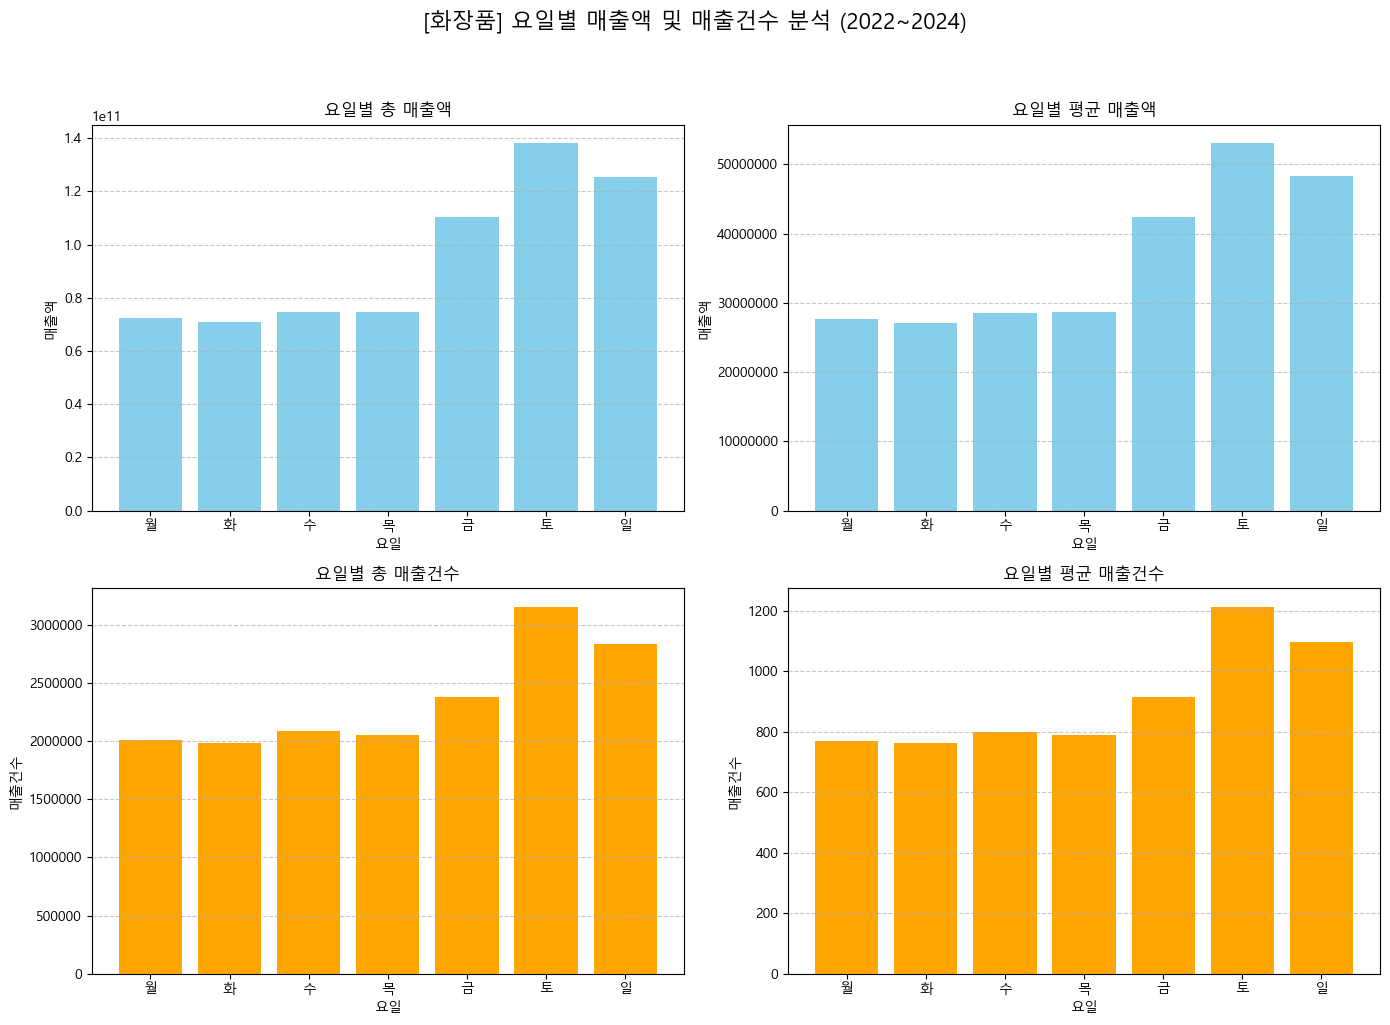

In [322]:
# -----------------
# 시각화
# -----------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# fig.suptitle('[패션잡화] 요일별 매출액 및 매출건수 분석 (2022~2024)', fontsize=16, y=1.02)
# fig.suptitle('[의류/의복] 요일별 매출액 및 매출건수 분석 (2022~2024)', fontsize=16, y=1.02)
fig.suptitle('[화장품] 요일별 매출액 및 매출건수 분석 (2022~2024)', fontsize=16, y=1.02)

plt.rcParams.update({'font.size': 10})

# 1) 요일별 총 매출액 (Top Left: axes[0, 0])
ax1 = axes[0, 0]
ax1.bar(df_agg['day'], df_agg['amt_sum'], color='skyblue')
ax1.set_xticks(df_agg['day'])
ax1.set_xticklabels(day_labels)
ax1.set_title('요일별 총 매출액')
ax1.set_xlabel('요일')
ax1.set_ylabel('매출액')
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # Y축 과학적 표기법
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2) 요일별 평균 매출액 (Top Right: axes[0, 1])
ax2 = axes[0, 1]
ax2.bar(df_agg['day'], df_agg['amt_mean'], color='skyblue')
ax2.set_xticks(df_agg['day'])
ax2.set_xticklabels(day_labels)
ax2.set_title('요일별 평균 매출액')
ax2.set_xlabel('요일')
ax2.set_ylabel('매출액')
ax2.ticklabel_format(axis='y', style='plain') # Y축 일반 표기법 (평균값은 sci limit이 낮아 plain이 나을 수 있음)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3) 요일별 총 매출건수 (Bottom Left: axes[1, 0])
ax3 = axes[1, 0]
ax3.bar(df_agg['day'], df_agg['cnt_sum'], color='orange')
ax3.set_xticks(df_agg['day'])
ax3.set_xticklabels(day_labels)
ax3.set_title('요일별 총 매출건수')
ax3.set_xlabel('요일')
ax3.set_ylabel('매출건수')
ax3.ticklabel_format(axis='y', style='plain') 
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# 4) 요일별 평균 매출건수 (Bottom Right: axes[1, 1])
ax4 = axes[1, 1]
ax4.bar(df_agg['day'], df_agg['cnt_mean'], color='orange')
ax4.set_xticks(df_agg['day'])
ax4.set_xticklabels(day_labels)
ax4.set_title('요일별 평균 매출건수')
ax4.set_xlabel('요일')
ax4.set_ylabel('매출건수')
ax4.ticklabel_format(axis='y', style='plain') 
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Step 1: 데이터 전처리 (일별 집계 & 로그 변환)

In [404]:
print("\n" + "=" * 70)
print("Step 1: 데이터 전처리")
print("=" * 70)


Step 1: 데이터 전처리


In [406]:
# ========================================
# 1-1) 일별 집계
# ========================================

daily = df_categories.groupby(['ta_ymd', 'day']).agg({
    'amt': 'sum',    # 총 매출액
    'cnt': 'sum'     # 총 거래 건수
}).reset_index('day')

In [408]:
daily.isnull().sum()

day    0
amt    0
cnt    0
dtype: int64

In [410]:
# 결측일 0으로 채우기
daily = daily.fillna(0)

print(f"\n【일별 집계 결과】")
print(f"  행 수: {len(daily)}")
print(f"  기간: {daily.index.min().date()} ~ {daily.index.max().date()}")
print(f"  결측 비율: {(daily['amt']==0).sum()/len(daily)*100:.2f}%")


【일별 집계 결과】
  행 수: 1095
  기간: 2022-01-01 ~ 2024-12-31
  결측 비율: 0.00%


In [412]:
# ========================================
# 1-2) 로그 변환 (분산 안정화)
# ========================================

daily['amt_log'] = np.log1p(daily['amt'])
daily['cnt_log'] = np.log1p(daily['cnt'])

# 거래당 평균금액 (AOV)
daily['aov'] = daily['amt'] / (daily['cnt'] + 1e-9)
daily['aov_log'] = np.log1p(daily['aov'])

In [414]:
daily.head()

,day,amt,cnt,amt_log,cnt_log,aov,aov_log
ta_ymd,,,,,,,
2022-01-01,6,180816195,7407,19.012992,8.910316,24411.528959,10.102852
2022-01-02,7,941269933,15602,20.662741,9.655218,60330.081592,11.007603
2022-01-03,1,387261248,10777,19.774610,9.285262,35934.049179,10.489468
2022-01-04,2,366278892,10468,19.718906,9.256174,34990.341230,10.462856
2022-01-05,3,348306797,10846,19.668594,9.291644,32113.848147,10.377074


In [416]:
print(f"\n【로그 변환 완료】")
print(f"  원본 매출액: {daily['amt'].describe()}")
print(f"  로그 매출액: {daily['amt_log'].describe()}")

# 기본 통계
print(f"\n【기본 통계】")
print(daily[['amt', 'cnt', 'amt_log', 'cnt_log']].describe())


【로그 변환 완료】
  원본 매출액: count    1.095000e+03
mean     6.085886e+08
std      2.400619e+08
min      7.230894e+07
25%      4.213042e+08
50%      5.554139e+08
75%      7.581486e+08
max      1.756982e+09
Name: amt, dtype: float64
  로그 매출액: count    1095.000000
mean       20.152598
std         0.388318
min        18.096458
25%        19.858866
50%        20.135224
75%        20.446390
max        21.286863
Name: amt_log, dtype: float64

【기본 통계】
                amt           cnt      amt_log      cnt_log
count  1.095000e+03   1095.000000  1095.000000  1095.000000
mean   6.085886e+08  15089.286758    20.152598     9.583233
std    2.400619e+08   4297.696577     0.388318     0.278435
min    7.230894e+07   2932.000000    18.096458     7.983781
25%    4.213042e+08  12009.000000    19.858866     9.393495
50%    5.554139e+08  14056.000000    20.135224     9.550876
75%    7.581486e+08  17933.500000    20.446390     9.794481
max    1.756982e+09  34557.000000    21.286863    10.450394


# Step 2: 더미 변수 생성 (블프, 공휴일)

In [418]:
print("\n" + "=" * 70)
print("Step 2: 더미 변수 생성")
print("=" * 70)


Step 2: 더미 변수 생성


In [420]:
# ========================================
# 2-1) 블랙프라이데이 기간 정의
# ========================================

# # 의류/의복, 패션잡화 블프 기간
# bf_2022 = pd.date_range(f'2022-11-14', f'2022-11-27', freq='D')
# bf_2023 = pd.date_range(f'2023-11-13', f'2023-11-26', freq='D')
# bf_2024 = pd.date_range(f'2024-11-18', f'2024-12-01', freq='D')

# 화장품 블프 기간
bf_2022 = pd.date_range(f'2022-11-01', f'2022-11-07', freq='D')
bf_2023 = pd.date_range(f'2023-11-01', f'2023-11-07', freq='D')
bf_2024 = pd.date_range(f'2024-11-01', f'2024-11-07', freq='D')

In [422]:
# ========================================
# 2-2) 블프 더미 생성
# ========================================

daily['is_bf'] = 0

for bf in [bf_2022, bf_2023, bf_2024]:
    start, end = bf[0], bf[-1]
    mask = (daily.index >= start) & (daily.index <= end)
    daily.loc[mask, 'is_bf'] = 1
    print(f"블프 기간: {start.date()} ~ {end.date()}")

블프 기간: 2022-11-01 ~ 2022-11-07
블프 기간: 2023-11-01 ~ 2023-11-07
블프 기간: 2024-11-01 ~ 2024-11-07


In [424]:
print(f"\n【블프 기간 통계】")
for year in [2022, 2023, 2024]:
    bf_count = daily[daily['is_bf']==1].index.year.value_counts().get(year, 0)
    print(f"  {year}: {bf_count}일")


【블프 기간 통계】
  2022: 7일
  2023: 7일
  2024: 7일


In [426]:
# ========================================
# 2-3) 공휴일 더미 생성
# ========================================

kr_holidays = holidays.KR(years=range(2022, 2025))

daily['is_holiday'] = daily.index.isin(kr_holidays).astype(int)

print(f"\n【공휴일 통계】")
print(f"  공휴일 총 개수: {daily['is_holiday'].sum()}일")
print(f"  공휴일 목록: {sorted(set(daily[daily['is_holiday']==1].index.strftime('%Y-%m-%d')))[:5]}... (이하 생략)")


【공휴일 통계】
  공휴일 총 개수: 56일
  공휴일 목록: ['2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02', '2022-03-01']... (이하 생략)


In [428]:
# ========================================
# 2-4) 최종 외생변수 행렬
# ========================================

exog = daily[['is_bf', 'is_holiday']]

print(f"\n【외생변수 행렬】")
print(exog.head(10))
print(f"  형태: {exog.shape}")


【외생변수 행렬】
            is_bf  is_holiday
ta_ymd                       
2022-01-01      0           1
2022-01-02      0           0
2022-01-03      0           0
2022-01-04      0           0
2022-01-05      0           0
2022-01-06      0           0
2022-01-07      0           0
2022-01-08      0           0
2022-01-09      0           0
2022-01-10      0           0
  형태: (1095, 2)


# Step 3: 이상치 탐지 & 처리

In [430]:
print("\n" + "=" * 70)
print("Step 3: 이상치 탐지 & 처리")
print("=" * 70)


Step 3: 이상치 탐지 & 처리


In [432]:
# ========================================
# 3-1) 롤링 MAD 기반 이상치 탐지
# ========================================

# 분석 대상
s = pd.Series(daily['amt_log'].values, index=daily.index).astype(float)
win = 7  # 7일 윈도우

# 중앙값 계산 (강건 레벨)
"""
- t일의 '로컬 대표값'을 중앙값으로 추정
- min_periods=3로 가장자리에서도 가능한 한 계산
- center=True: 현재 일 기준 +-3일 포함 (즉, Day-3 ~ Day+5)
- 예: Day5의 중앙값 = [Day2, Day3, Day4, Day5, Day6, Day7, Day8]의 중앙값
"""
mu = s.rolling(win, center=True, min_periods=3).median()

# 중앙절대편차(MAD) 계산 (강건 산포)
"""
Step 1: 편차 = 원본 - 중앙값
Step 2: 절대값
Step 3: 그 절대값의 중앙값
예: Day5 근처 데이터들의 "편차 정도"를 로컬 기준으로 측정
"""
dev = (s - mu).abs()
mad = dev.rolling(win, center=True, min_periods=3).median()

# Robust Z-score 계산 (강건 Z 점수)
"""
- 1.4826: 표준정규분포에서 MAD를 표준편차 스케일로 보정하는 상수
- replace(0, np.nan): 0으로 나누는 것 방지 (분모가 0이 되는 극단 경우)
- 해석: 각 일이 "주변 기준에서 몇 표준편차 벗어났는가?"
"""
rob_z = (s - mu) / (1.4826 * mad.replace(0, np.nan))

# 가장자리/분모 NaN 보정(선택)
# 가장자리 및 결측으로 생긴 NaN을 0으로 채워 탐지 계산을 이어감
rob_z = rob_z.fillna(0)

"""
- rob_z > 4 ⟹ 매우 극단적인 이상치
- rob_z > 3 ⟹ 보통 이상치
"""
daily['rob_z'] = rob_z
daily['is_outlier'] = (rob_z.abs() > 4).astype(int)

print(f"\n【이상치 탐지】")
print(f"  탐지된 이상치: {daily['is_outlier'].sum()}개")

# 이상치 목록
outliers = daily[daily['is_outlier']==1][['amt_log', 'rob_z', 'is_bf', 'is_holiday', 'day']]
print(f"\n【이상치 목록】")
print(outliers)


【이상치 탐지】
  탐지된 이상치: 38개

【이상치 목록】
              amt_log      rob_z  is_bf  is_holiday  day
ta_ymd                                                  
2022-01-02  20.662741   6.004838      0           0    7
2022-02-01  18.096458  -4.907161      0           1    2
2022-02-26  20.630136   4.397977      0           0    6
2022-03-13  20.394124   5.439473      0           0    7
2022-04-09  20.743426   5.623110      0           0    6
2022-05-20  20.702276   4.130478      0           0    5
2022-07-04  18.988608  -5.622747      0           0    1
2022-09-10  18.517624  -5.986026      0           1    6
2022-09-24  20.716070   4.387817      0           0    6
2022-09-25  20.676068   4.279562      0           0    7
2023-01-14  20.363828   5.231644      0           0    6
2023-01-15  20.353934   5.125078      0           0    7
2023-01-22  18.385786  -6.461428      0           1    7
2023-02-11  20.616650   7.103387      0           0    6
2023-02-12  20.431430   5.356095      0           0  

In [78]:
# 이따가 이상치 한 번 비교해보자
cloth_outliers = outliers

In [434]:
cosmetic_outliers = outliers

In [436]:
# ========================================
# 3-2) 이벤트 로그와 대조
# ========================================

print(f"\n【이상치 분류】")
for date, row in outliers.iterrows():
    if row['is_bf'] == 1:
        print(f"  {date.date()}: 블프 기간 (설명 가능) ✓")
    elif row['is_holiday'] == 1:
        print(f"  {date.date()}: 공휴일 (설명 가능) ✓")
    else:
        print(f"  {date.date()}: 모니터링 필요 ⚠️")


【이상치 분류】
  2022-01-02: 모니터링 필요 ⚠️
  2022-02-01: 공휴일 (설명 가능) ✓
  2022-02-26: 모니터링 필요 ⚠️
  2022-03-13: 모니터링 필요 ⚠️
  2022-04-09: 모니터링 필요 ⚠️
  2022-05-20: 모니터링 필요 ⚠️
  2022-07-04: 모니터링 필요 ⚠️
  2022-09-10: 공휴일 (설명 가능) ✓
  2022-09-24: 모니터링 필요 ⚠️
  2022-09-25: 모니터링 필요 ⚠️
  2023-01-14: 모니터링 필요 ⚠️
  2023-01-15: 모니터링 필요 ⚠️
  2023-01-22: 공휴일 (설명 가능) ✓
  2023-02-11: 모니터링 필요 ⚠️
  2023-02-12: 모니터링 필요 ⚠️
  2023-02-17: 모니터링 필요 ⚠️
  2023-03-12: 모니터링 필요 ⚠️
  2023-03-18: 모니터링 필요 ⚠️
  2023-03-19: 모니터링 필요 ⚠️
  2023-05-14: 모니터링 필요 ⚠️
  2023-07-28: 모니터링 필요 ⚠️
  2023-07-29: 모니터링 필요 ⚠️
  2023-09-10: 모니터링 필요 ⚠️
  2023-09-15: 모니터링 필요 ⚠️
  2023-09-16: 모니터링 필요 ⚠️
  2023-09-29: 공휴일 (설명 가능) ✓
  2023-10-20: 모니터링 필요 ⚠️
  2023-10-21: 모니터링 필요 ⚠️
  2023-10-22: 모니터링 필요 ⚠️
  2023-12-03: 모니터링 필요 ⚠️
  2024-01-13: 모니터링 필요 ⚠️
  2024-03-23: 모니터링 필요 ⚠️
  2024-03-24: 모니터링 필요 ⚠️
  2024-03-30: 모니터링 필요 ⚠️
  2024-09-14: 모니터링 필요 ⚠️
  2024-09-23: 모니터링 필요 ⚠️
  2024-12-01: 모니터링 필요 ⚠️
  2024-12-07: 모니터링 필요 ⚠️


In [438]:
# 3-3) 명백한 오류 제거 (선택)
# 예: 특정 날짜 데이터 오류 알려진 경우
# daily = daily[~((daily.index == '2024-`01-15') & (daily['is_outlier']==1))]

print(f"\n【이상치 처리 완료】")
print(f"  최종 데이터: {len(daily)}행")


【이상치 처리 완료】
  최종 데이터: 1095행


In [440]:
daily.head()

,day,amt,cnt,amt_log,cnt_log,aov,aov_log,is_bf,is_holiday,rob_z,is_outlier
ta_ymd,,,,,,,,,,,
2022-01-01,6,180816195,7407,19.012992,8.910316,24411.528959,10.102852,0,1,-1.240369,0
2022-01-02,7,941269933,15602,20.662741,9.655218,60330.081592,11.007603,0,0,6.004838,1
2022-01-03,1,387261248,10777,19.774610,9.285262,35934.049179,10.489468,0,0,0.484716,0
2022-01-04,2,366278892,10468,19.718906,9.256174,34990.341230,10.462856,0,0,0.000000,0
2022-01-05,3,348306797,10846,19.668594,9.291644,32113.848147,10.377074,0,0,-0.674491,0


# Step 4: EDA (탐색적 데이터 분석)

In [442]:
print("\n" + "=" * 70)
print("Step 4: EDA (탐색적 데이터 분석)")
print("=" * 70)


Step 4: EDA (탐색적 데이터 분석)


### 기본 통계

In [787]:
daily

,day,amt,cnt,amt_log,cnt_log,aov,aov_log,is_bf,is_holiday,rob_z,is_outlier
ta_ymd,,,,,,,,,,,
2022-01-01,6,144692672,5519,18.790123,8.616133,26217.190071,10.174209,0,1,-0.903272,0
2022-01-02,7,126003479,4888,18.651820,8.494743,25778.125818,10.157320,0,0,-1.752509,0
2022-01-03,1,172278104,5561,18.964621,8.623713,30979.698615,10.341120,0,0,0.326107,0
2022-01-04,2,178175134,5709,18.998278,8.649974,31209.517253,10.348510,0,0,0.260189,0
2022-01-05,3,158064955,5827,18.878517,8.670429,27126.300841,10.208296,0,0,-0.889221,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,5,191285979,3870,19.069280,8.261268,49427.901550,10.808291,0,0,0.000000,0
2024-12-28,6,217327907,5244,19.196918,8.565031,41443.155416,10.632102,0,0,2.056674,0
2024-12-29,7,116787439,3843,18.575866,8.254269,30389.653656,10.321890,0,0,-4.093954,1


In [788]:
daily.shape

(1095, 11)

In [789]:
daily.columns

Index(['day', 'amt', 'cnt', 'amt_log', 'cnt_log', 'aov', 'aov_log', 'is_bf',
       'is_holiday', 'rob_z', 'is_outlier'],
      dtype='object')

In [790]:
daily.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1095 entries, 2022-01-01 to 2024-12-31
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         1095 non-null   int64  
 1   amt         1095 non-null   int64  
 2   cnt         1095 non-null   int64  
 3   amt_log     1095 non-null   float64
 4   cnt_log     1095 non-null   float64
 5   aov         1095 non-null   float64
 6   aov_log     1095 non-null   float64
 7   is_bf       1095 non-null   int64  
 8   is_holiday  1095 non-null   int32  
 9   rob_z       1095 non-null   float64
 10  is_outlier  1095 non-null   int32  
dtypes: float64(5), int32(2), int64(4)
memory usage: 94.1 KB


In [791]:
daily.isnull().sum()

day           0
amt           0
cnt           0
amt_log       0
cnt_log       0
aov           0
aov_log       0
is_bf         0
is_holiday    0
rob_z         0
is_outlier    0
dtype: int64

In [792]:
daily[['amt', 'amt_log', 'cnt', 'cnt_log', 'aov', 'aov_log', 'rob_z']].describe()

,amt,amt_log,cnt,cnt_log,aov,aov_log,rob_z
count,1.095000e+03,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,1.854427e+08,19.001859,5083.660274,8.494535,38255.591156,10.507565,-0.227754
std,4.943134e+07,0.276545,1503.229844,0.276410,11694.299394,0.298010,2.012811
min,3.311591e+07,17.315524,1681.000000,7.427739,15898.178589,9.674023,-19.782944
25%,1.538514e+08,18.851498,4096.000000,8.318010,29459.017073,10.290789,-0.674491
50%,1.817402e+08,19.018089,4556.000000,8.424420,37194.093743,10.523932,0.000000
75%,2.134680e+08,19.178997,5964.000000,8.693664,44813.755995,10.710293,0.674491
max,4.574583e+08,19.941196,12371.000000,9.423191,90139.573399,11.409126,11.793106


array([[<Axes: title={'center': 'day'}>, <Axes: title={'center': 'amt'}>,
        <Axes: title={'center': 'cnt'}>],
       [<Axes: title={'center': 'amt_log'}>,
        <Axes: title={'center': 'cnt_log'}>,
        <Axes: title={'center': 'aov'}>],
       [<Axes: title={'center': 'aov_log'}>,
        <Axes: title={'center': 'is_bf'}>,
        <Axes: title={'center': 'is_holiday'}>],
       [<Axes: title={'center': 'rob_z'}>,
        <Axes: title={'center': 'is_outlier'}>, <Axes: >]], dtype=object)

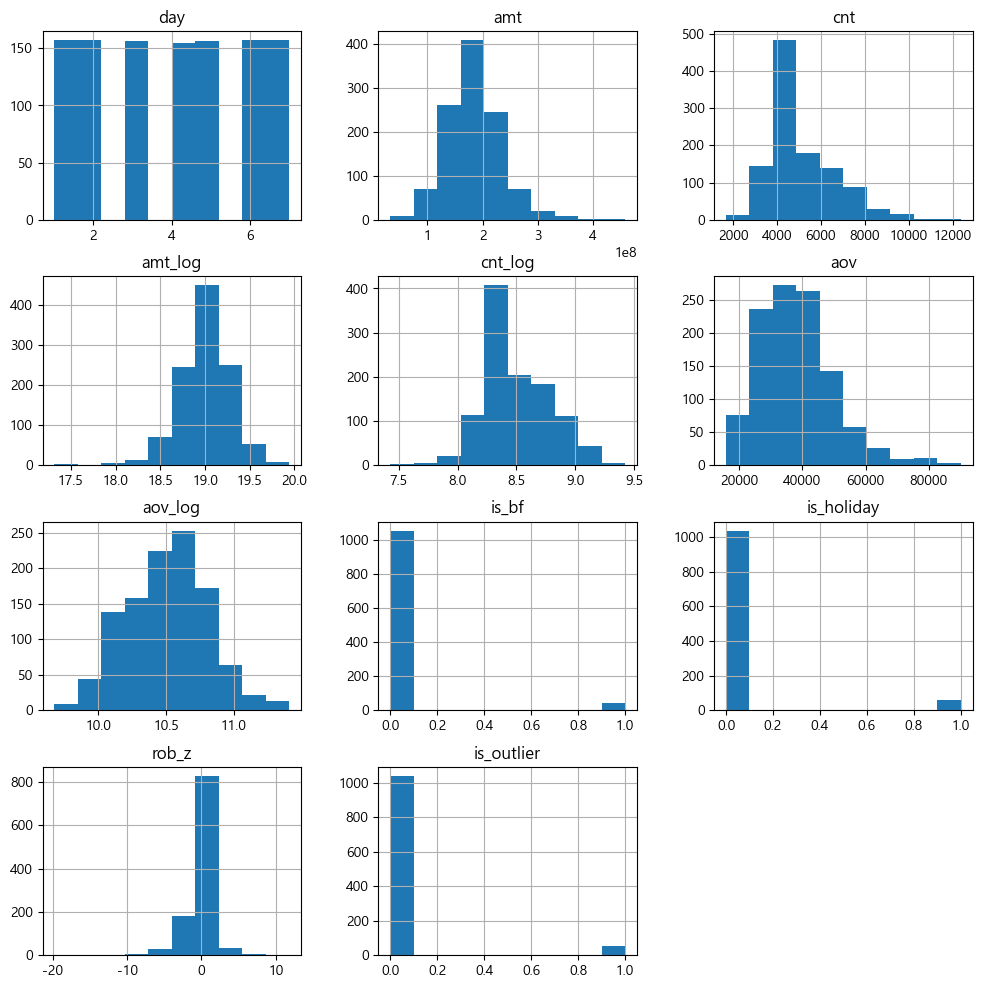

In [793]:
daily.hist(figsize=(12,12))

## 시각화

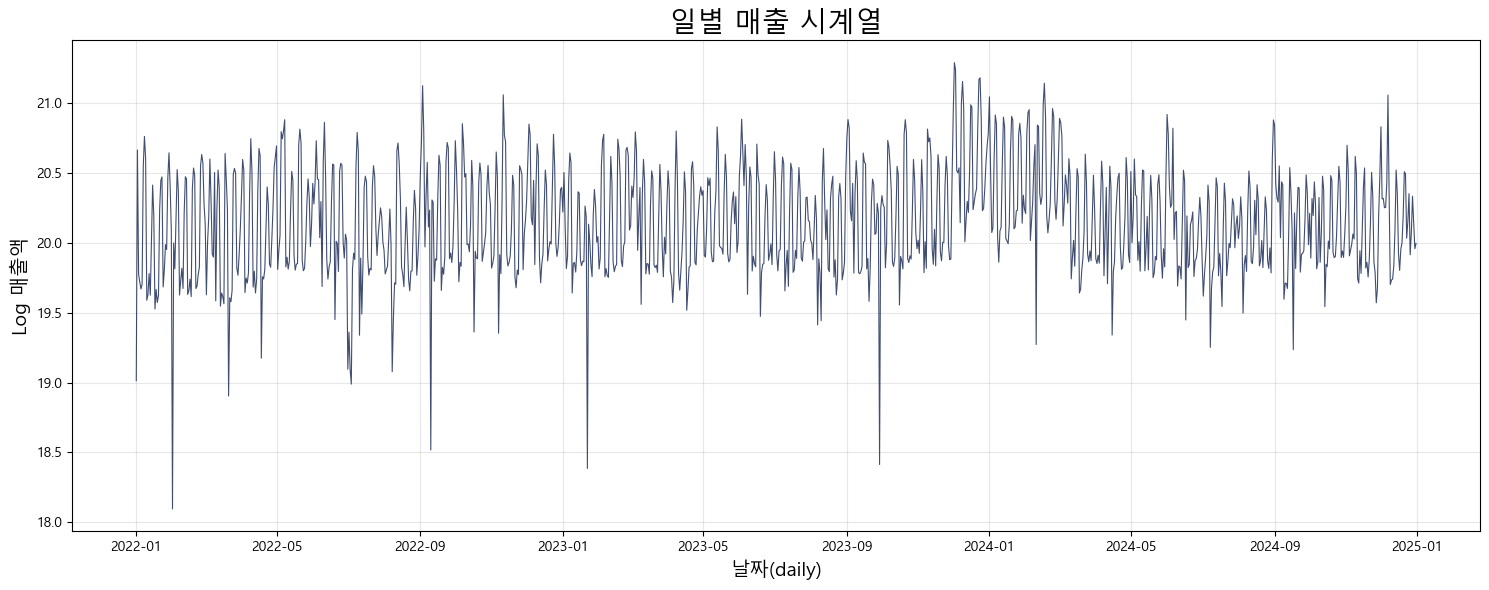

In [444]:
# ========================================
# 4-1) 시계열 플롯
# ========================================

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(daily.index, daily['amt_log'], color='#11224E', alpha=0.8, linewidth=0.8)
ax.set_xlabel('날짜(daily)', fontsize=14)
ax.set_ylabel('Log 매출액', fontsize=14)
ax.set_title('일별 매출 시계열', fontsize=20)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

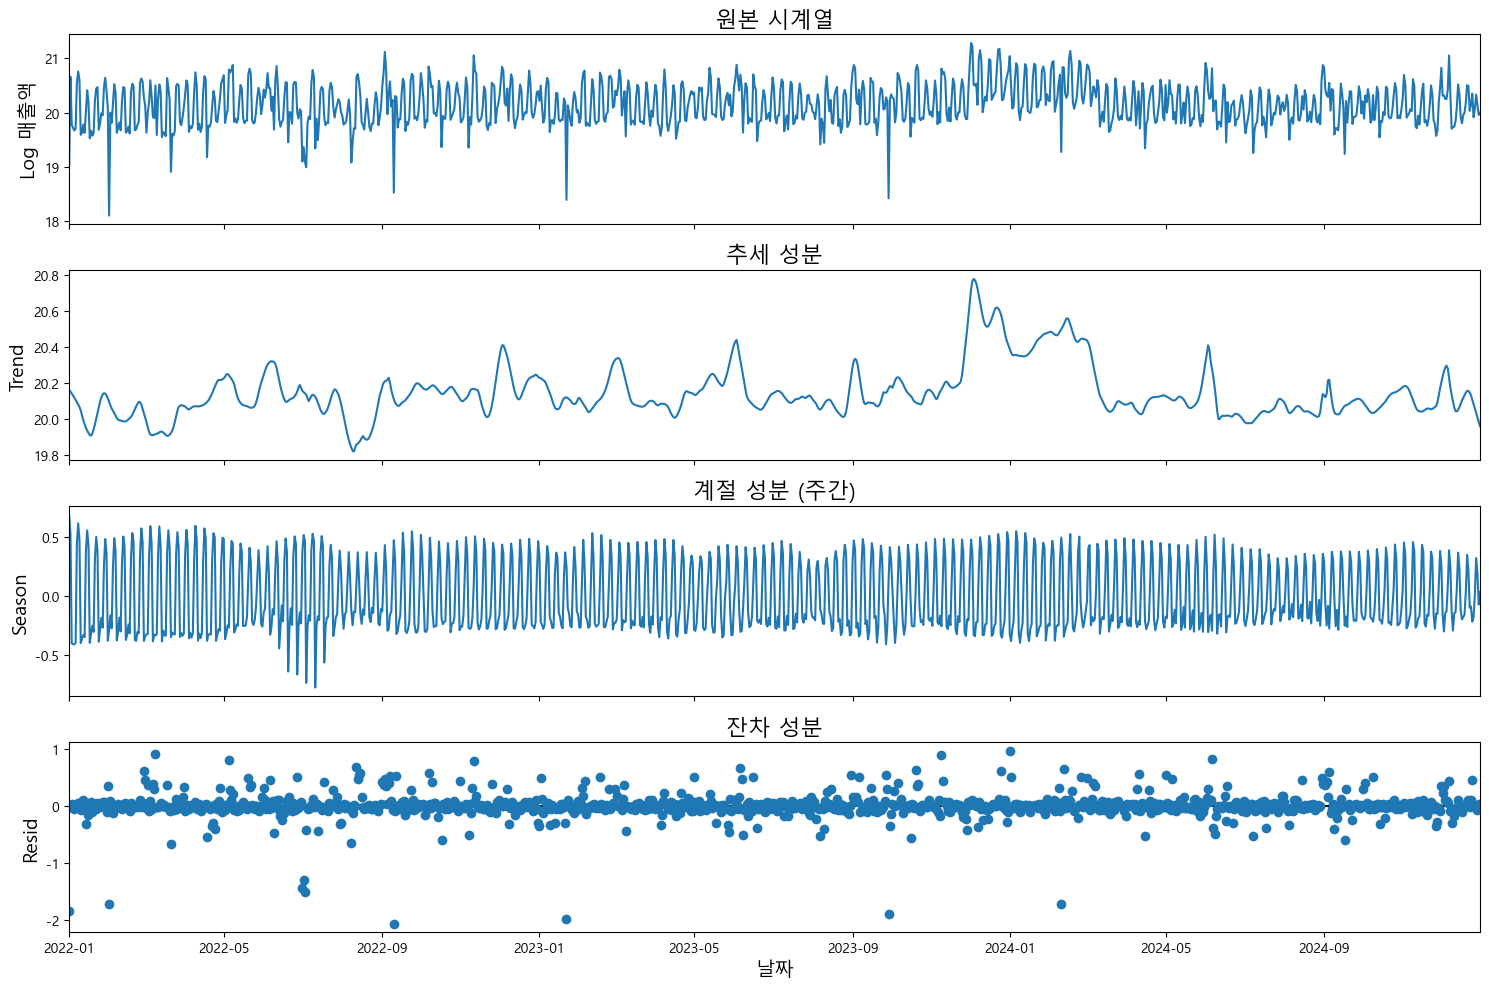

In [446]:
# ========================================
# 4-2) STL 분해 (추세 + 계절 + 잔차)
# ========================================

# 계절 주기 7일로 설정
stl = STL(daily['amt_log'], period=7, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(15, 10)

axes = fig.axes

# axes[0] : 원본 데이터 (amt_log)
axes[0].set_ylabel('Log 매출액', fontsize=14)
axes[0].set_title('원본 시계열', fontsize=16)

# axes[1] : 추세 (Trend)
axes[1].set_ylabel('Trend', fontsize=14) 
axes[1].set_title('추세 성분', fontsize=16) 

# axes[2] : 계절성 (Season)
axes[2].set_ylabel('Season', fontsize=14)
axes[2].set_title('계절 성분 (주간)', fontsize=16) 

# axes[3] : 잔차 (Residual)
axes[3].set_ylabel('Resid', fontsize=14)
axes[3].set_title('잔차 성분', fontsize=16)
axes[3].set_xlabel('날짜', fontsize=14)

plt.tight_layout()
plt.show()

In [448]:
# 분해 성분 분석
trend = stl.trend
seasonal = stl.seasonal
residual = stl.resid

print(f"\n【분해 성분 통계】")
print(f"  1. 추세 범위: {trend.min():.3f} ~ {trend.max():.3f} -> {(trend.max()-trend.min()):.3f}")
print(f"  2. 계절 범위: {seasonal.min():.3f} ~ {seasonal.max():.3f} -> {(seasonal.max()-seasonal.min()):.3f}")
print(f"  3. 잔차 범위: {residual.min():.3f} ~ {residual.max():.3f} -> {(residual.max()-residual.min()):.3f}")


【분해 성분 통계】
  1. 추세 범위: 19.819 ~ 20.777 -> 0.958
  2. 계절 범위: -0.773 ~ 0.684 -> 1.456
  3. 잔차 범위: -2.063 ~ 0.972 -> 3.035


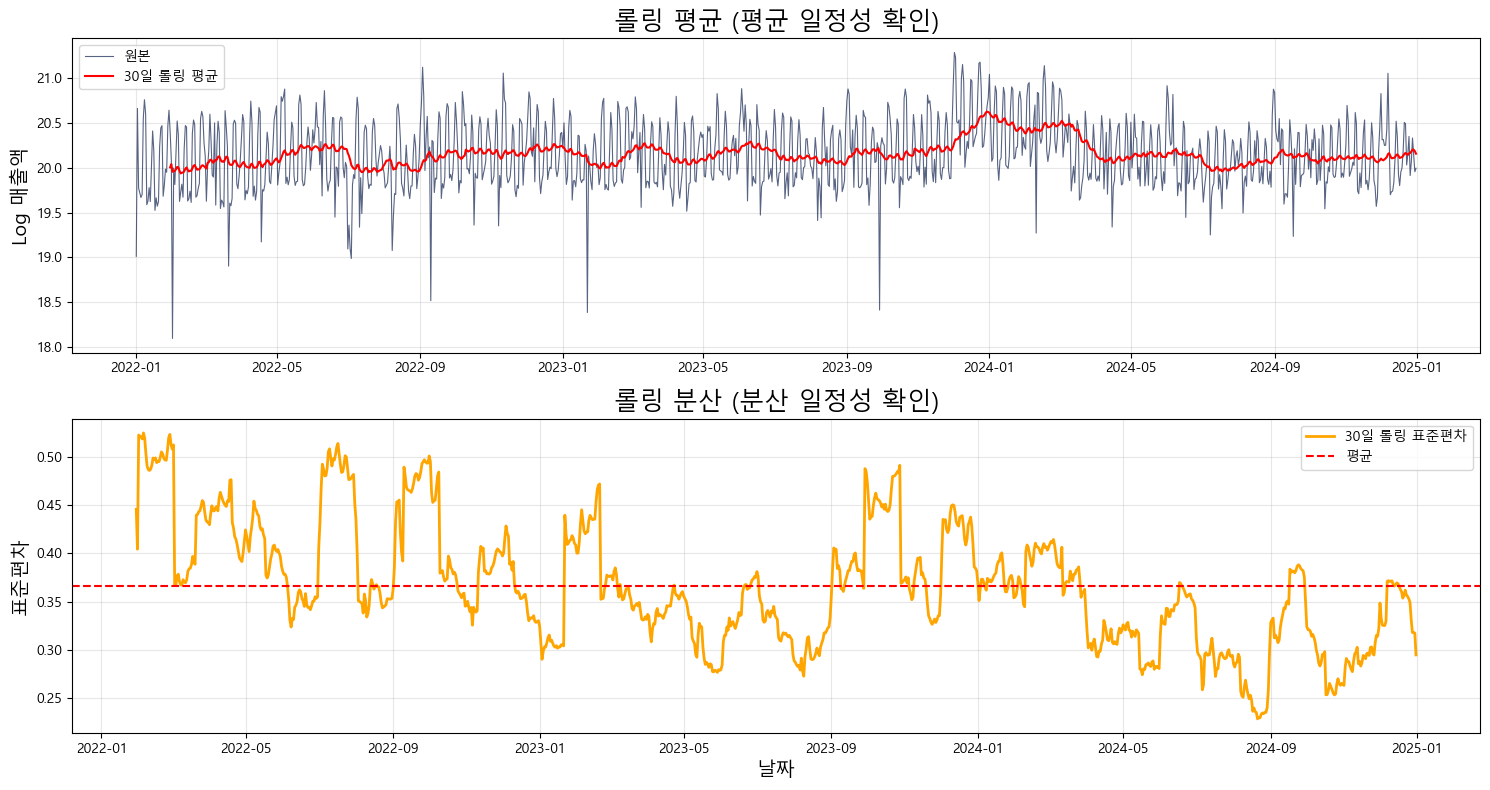

In [450]:
# ========================================
# 4-3) 롤링 평균/분산 (정상성 시각화)
# ========================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# 롤링 평균
rolling_mean = daily['amt_log'].rolling(30).mean()
axes[0].plot(daily.index, daily['amt_log'], label='원본', color='#11224E', alpha=0.7, linewidth=0.8)
axes[0].plot(daily.index, rolling_mean, label='30일 롤링 평균', linewidth=1.5, color='red')
axes[0].set_ylabel('Log 매출액', fontsize=14)
axes[0].set_title('롤링 평균 (평균 일정성 확인)', fontsize=18)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 롤링 표준편차
rolling_std = daily['amt_log'].rolling(30).std()
axes[1].plot(daily.index, rolling_std, label='30일 롤링 표준편차', color='orange', linewidth=2)
axes[1].axhline(y=rolling_std.mean(), color='red', linestyle='--', label='평균')
axes[1].set_ylabel('표준편차', fontsize=14)
axes[1].set_xlabel('날짜', fontsize=14)
axes[1].set_title('롤링 분산 (분산 일정성 확인)', fontsize=18)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

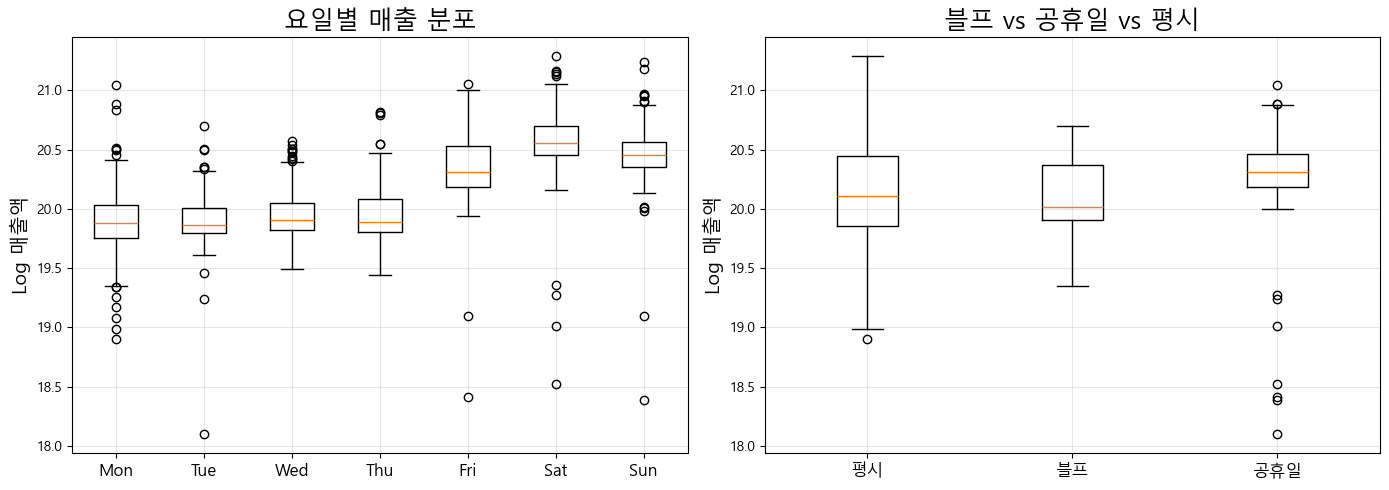

In [484]:
# ========================================
# 4-4) 달력 효과 (박스플롯)
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 요일별
dow_data = [daily[daily['day']==i]['amt_log'].values for i in range(1, 8)]
axes[0].boxplot(dow_data, labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0].set_ylabel('Log 매출액', fontsize=14)
axes[0].set_title('요일별 매출 분포', fontsize=18)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', labelsize=12)

# 블프 vs 공휴일 vs 평시
bf_data = daily[(daily['is_bf'] == 0) & (daily['is_holiday'] == 0)]['amt_log'].values
nbf_data = daily[(daily['is_bf'] == 1) & (daily['is_holiday'] == 0)]['amt_log'].values
hol_data = daily[(daily['is_bf'] == 0) & (daily['is_holiday'] == 1)]['amt_log'].values
axes[1].boxplot([bf_data, nbf_data, hol_data], labels=['평시', '블프', '공휴일'])
axes[1].set_ylabel('Log 매출액', fontsize=14)
axes[1].set_title('블프 vs 공휴일 vs 평시', fontsize=18)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

# Step 5: 정상성 검정 (ADF/KPSS)

In [454]:
print("\n" + "=" * 70)
print("Step 5: 정상성 검정 (단위근 검정)")
print("=" * 70)


Step 5: 정상성 검정 (단위근 검정)


In [458]:
# ========================================
# 5-1) 원본 정상성 검정
# ========================================
"""
adfuller: ADF 검정
kpss: KPSS 검정
"""

adf_stat_raw, adf_p_raw = adfuller(daily['amt_log'])[:2]
kpss_stat_raw, kpss_p_raw = kpss(daily['amt_log'])[:2]

print(f"\n【원본 정상성 검정】")
print(f"  ADF: statistic = {adf_stat_raw:.4f}, p-value = {adf_p_raw:.4f}")
print(f"       → {'정상' if adf_p_raw <= 0.05 else '비정상'}")
print(f"  KPSS: statistic = {kpss_stat_raw:.4f}, p-value = {kpss_p_raw:.4f}")
print(f"        → {'정상' if kpss_p_raw > 0.05 else '비정상'}")


【원본 정상성 검정】
  ADF: statistic = -4.0426, p-value = 0.0012
       → 정상
  KPSS: statistic = 0.5876, p-value = 0.0238
        → 비정상


#### 1차 차분 후 정상성 검정

In [609]:
# ========================================
# 5-2) 1차 차분 후 정상성 검정
# ========================================
"""
위에서 정상성을 만족했으면 차분할 필요가 없음!
"""

y_diff = daily['amt_log'].diff().dropna()

adf_stat_diff, adf_p_diff = adfuller(y_diff)[:2]
kpss_stat_diff, kpss_p_diff = kpss(y_diff)[:2]

print(f"\n【1차 차분 후 정상성 검정】")
print(f"  ADF: statistic={adf_stat_diff:.4f}, p-value={adf_p_diff:.4f}")
print(f"       → {'정상' if adf_p_diff <= 0.05 else '비정상'}")
print(f"  KPSS: statistic={kpss_stat_diff:.4f}, p-value={kpss_p_diff:.4f}")
print(f"        → {'정상' if kpss_p_diff > 0.05 else '비정상'}")


【1차 차분 후 정상성 검정】
  ADF: statistic=-11.4116, p-value=0.0000
       → 정상
  KPSS: statistic=0.1183, p-value=0.1000
        → 정상


#### 계절 차분 후 정상성 검정

In [482]:
# ========================================
# 5-2) 계절 차분 후 정상성 검정
# ========================================

y_diff7 = daily['amt_log'].diff(7).dropna()

adf_stat, adf_p = adfuller(y_diff7)[:2]
kpss_stat, kpss_p = kpss(y_diff7)[:2]

print(f"【계절 차분(diff(7)) 후 정상성 검정】")
print(f"  ADF p-value: {adf_p:.4f} (0.05 이하면 정상)")
print(f"       → {'정상' if adf_p_diff <= 0.05 else '비정상'}")
print(f"  KPSS p-value: {kpss_p:.4f} (0.05 초과면 정상)")
print(f"        → {'정상' if kpss_p_diff > 0.05 else '비정상'}")

【계절 차분(diff(7)) 후 정상성 검정】
  ADF p-value: 0.0000 (0.05 이하면 정상)
       → 정상
  KPSS p-value: 0.1000 (0.05 초과면 정상)
        → 정상


In [462]:
# ========================================
# 5-3) d 차수 결정
# ========================================

if adf_p_raw <= 0.05 and kpss_p_raw > 0.05:
    d_final = 0
    print(f"\n【결론】d = 0 (차분 불필요)")
elif adf_p_diff <= 0.05 and kpss_p_diff > 0.05:
    d_final = 1
    print(f"\n【결론】d = 1 (1차 차분 필요)")


【결론】d = 1 (1차 차분 필요)


# Step 6: 모형 식별 (ACF/PACF)

In [464]:
print("\n" + "=" * 70)
print("Step 6: 모형 식별")
print("=" * 70)


Step 6: 모형 식별


#### 차분 필요 없을 경우

In [ ]:
# ========================================
# 6-1) ACF/PACF 시각화
# ========================================

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 원본
# plot_acf(daily['amt_log'], lags=40, ax=axes[0])
# axes[0].set_title('ACF (원본)', fontsize=18)
# plot_pacf(daily['amt_log'], lags=40, ax=axes[1])
# axes[1].set_title('PACF (원본)', fontsize=18)

#### 1차 차분 필요할 경우

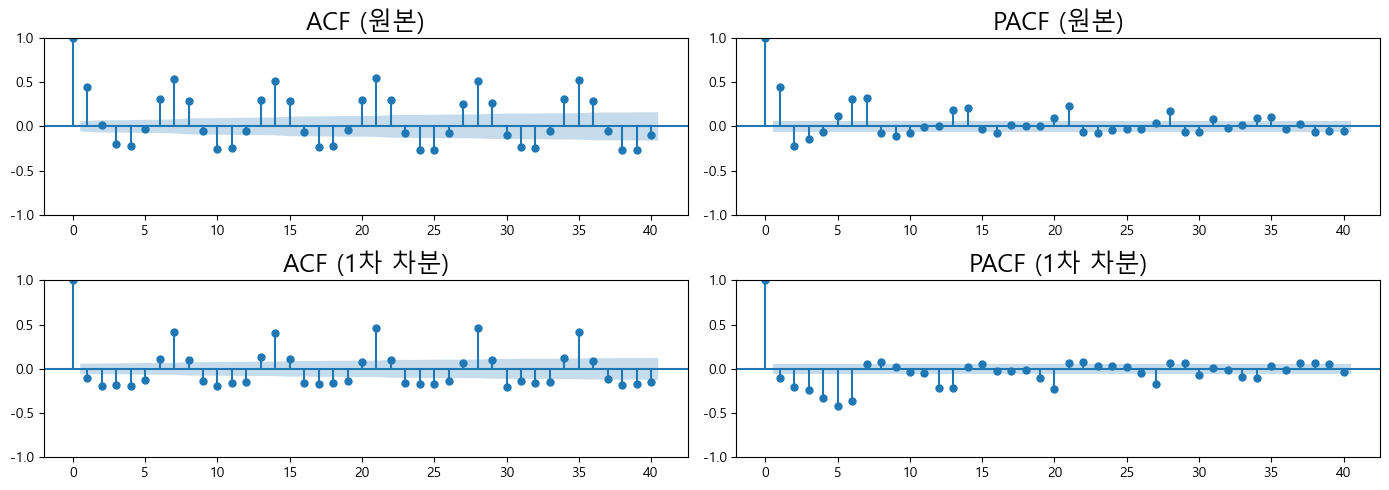

In [466]:
# ========================================
# 6-1) ACF/PACF 시각화
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 5))

plot_acf(daily['amt_log'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF (원본)', fontsize=18)
plot_pacf(daily['amt_log'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title('PACF (원본)', fontsize=18)

# 1차 차분
y_diff = daily['amt_log'].diff().dropna()
plot_acf(y_diff, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF (1차 차분)', fontsize=18)
plot_pacf(y_diff, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('PACF (1차 차분)', fontsize=18)

plt.tight_layout()
plt.show()

#### 계절 차분 필요할 경우

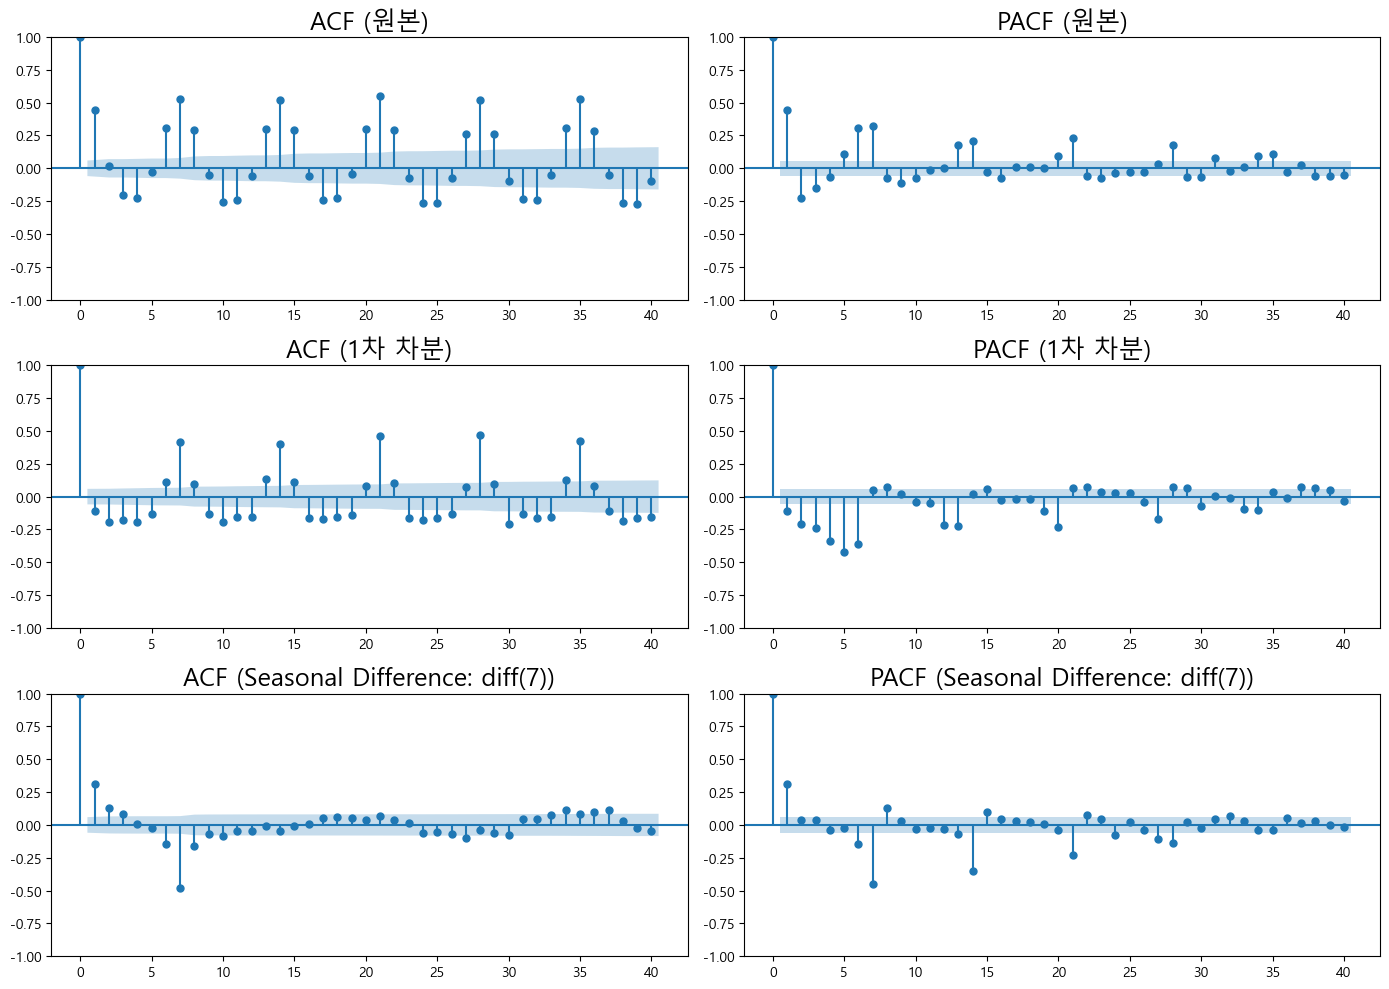

In [486]:
# ========================================
# 6-1) ACF/PACF 시각화
# ========================================
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# 원본
plot_acf(daily['amt_log'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF (원본)', fontsize=18)
plot_pacf(daily['amt_log'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title('PACF (원본)', fontsize=18)

# 1차 차분 -> 추세 제거용
y_diff = daily['amt_log'].diff().dropna()
plot_acf(y_diff, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF (1차 차분)', fontsize=18)
plot_pacf(y_diff, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('PACF (1차 차분)', fontsize=18)

# 계절 차분 (D=1, m=7) -> 주간 패턴 제거용
y_diff7 = daily['amt_log'].diff(7).dropna()

plot_acf(y_diff7, lags=40, ax=axes[2, 0])
axes[2, 0].set_title('ACF (Seasonal Difference: diff(7))', fontsize=18)
plot_pacf(y_diff7, lags=40, ax=axes[2, 1])
axes[2, 1].set_title('PACF (Seasonal Difference: diff(7))', fontsize=18)

plt.tight_layout()
plt.show()

# Step 7: SARIMAX 모형 적합 & 진단


In [489]:
print("\n" + "=" * 70)
print("Step 7: SARIMAX 모형 적합 & 진단")
print("=" * 70)


Step 7: SARIMAX 모형 적합 & 진단


In [491]:
# ========================================
# 7-1) 최적 모형 적합
# ========================================

# 데이터 준비
y = daily['amt_log']
X = exog    # 외생변수(exog)를 X로 지정 (pmdarima의 요구사항)

print("Auto-ARIMA 탐색을 시작합니다...")
print(f"데이터: {y.name}, 외생변수: {list(X.columns)}")

"""
2. auto_arima 실행
-----------------------------------------------------------------
AIC 값을 기준으로 최적 모델 결정

**중요 설정:**
m=7 : 계절성 주기 (매우 중요)
d=0, D=0 : 사용자의 기존 모델에서 (0, 0)이었으므로 고정
          (만약 차분을 auto_arima가 찾게 하려면 d=None, D=None)

**탐색 범위:**
max_p=2, max_q=2 : 비계절성 p,q 최대 2까지 탐색 (조절 가능)
max_P=2, max_Q=2 : 계절성 P,Q 최대 2까지 탐색 (조절 가능)

**옵션:**
trace=True : 탐색하는 모든 모델의 AIC 점수를 실시간으로 출력
stepwise=True : 모든 조합이 아닌, 효율적인 방식으로 빠르게 탐색
-----------------------------------------------------------------
"""

try:
    auto_arima_fit = pm.auto_arima(
        y,                  # 시계열 데이터
        X=X,                # 외생 변수
        m=7,                # 계절성 주기 (7일)
        d=0,                # 비계절성 차분 (사용자 모델 기준 0으로 고정)
        D=1,                # 계절성 차분 (사용자 모델 기준 0으로 고정)
        
        start_p=0,          # p 시작 값
        start_q=0,          # q 시작 값
        max_p=2,            # p 최대 탐색 값
        max_q=2,            # q 최대 탐색 값
        
        seasonal=True,      # 계절성 모델 사용
        start_P=0,          # P 시작 값
        start_Q=0,          # Q 시작 값
        max_P=2,            # P 최대 탐색 값
        max_Q=2,            # Q 최대 탐색 값
        
        stepwise=True,      # 효율적인 단계적 탐색 사용 (빠름)
        trace=True,         # 탐색 과정을 모두 출력
        suppress_warnings=True # 경고 메시지 숨기기
    )

    print("\n" + "="*50)
    print("✨ 탐색 완료! 최적의 모델을 찾았습니다.")
    print(auto_arima_fit.summary())
    
    # 찾은 최적의 order 확인
    print(f"\n최적의 비계절 order (p,d,q): {auto_arima_fit.order}")
    print(f"최적의 계절 order (P,D,Q,m): {auto_arima_fit.seasonal_order}")

except Exception as e:
    print(f"\nauto_arima 실행 중 오류 발생: {e}")
    print("탐색 범위(max_p, max_q)가 너무 크거나 데이터에 문제가 있을 수 있습니다.")

Auto-ARIMA 탐색을 시작합니다...
데이터: amt_log, 외생변수: ['is_bf', 'is_holiday']
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=951.777, Time=0.19 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=530.189, Time=1.15 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=213.944, Time=1.76 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=949.796, Time=0.19 sec
 ARIMA(0,0,1)(0,1,0)[7] intercept   : AIC=839.603, Time=0.34 sec
 ARIMA(0,0,1)(1,1,1)[7] intercept   : AIC=214.559, Time=1.99 sec
 ARIMA(0,0,1)(0,1,2)[7] intercept   : AIC=214.327, Time=4.66 sec
 ARIMA(0,0,1)(1,1,0)[7] intercept   : AIC=551.088, Time=1.08 sec
 ARIMA(0,0,1)(1,1,2)[7] intercept   : AIC=217.145, Time=5.32 sec
 ARIMA(0,0,0)(0,1,1)[7] intercept   : AIC=352.292, Time=1.14 sec
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=175.679, Time=2.37 sec
 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=825.868, Time=0.76 sec
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=174.412, Time=2.83 sec
 ARIMA(1,0,1)(1,1,0)[7] intercept   : AIC=53

In [493]:
# ========================================
# 7-2) 잔차 추출
# ========================================

residuals = auto_arima_fit.resid()

print(f"\n【잔차 기본 통계】")
print(f"  평균: {residuals.mean():.6f}")
print(f"  표준편차: {residuals.std():.4f}")
print(f"  최소: {residuals.min():.4f}")
print(f"  최대: {residuals.max():.4f}")


【잔차 기본 통계】
  평균: 0.131820
  표준편차: 1.6040
  최소: -2.2254
  최대: 20.6627


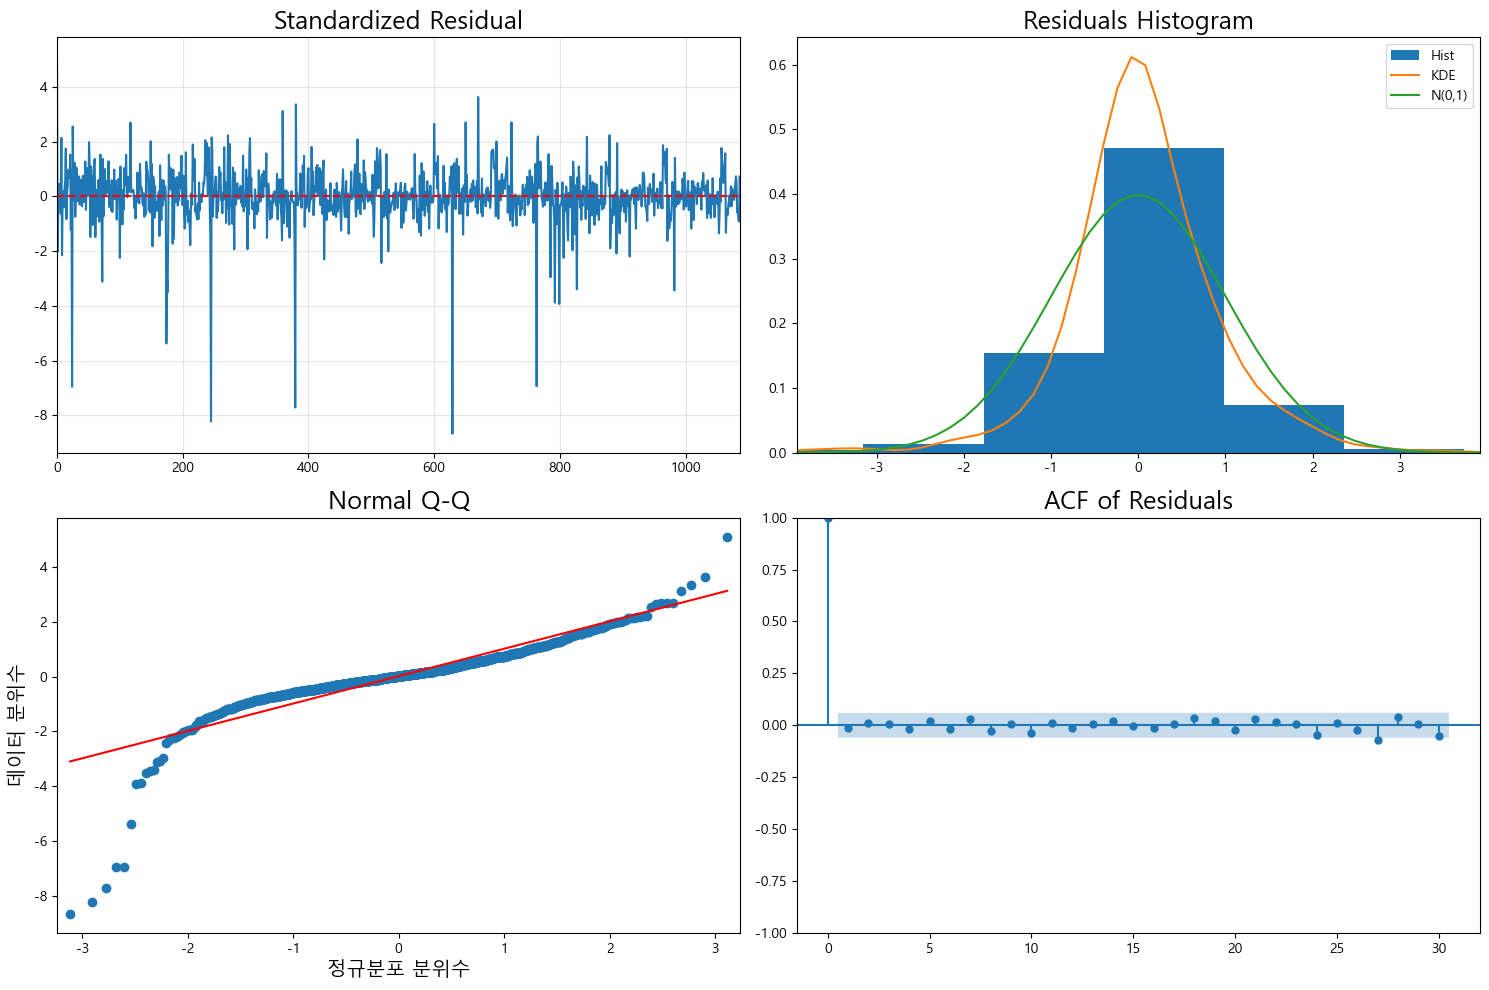

In [495]:
# ========================================
# 7-3) 잔차 진단 (4개 그래프)
# ========================================
# auto_arima_fit 객체에 .plot_diagnostics() 메서드를 사용

try:
    fig = auto_arima_fit.plot_diagnostics(figsize=(15, 10), lags=30)
    axes = fig.get_axes()
    
    # 1) 잔차 시계열
    axes[0].set_title('Standardized Residual', fontsize=18)
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].grid(True, alpha=0.3)

    # 2) 히스토그램
    axes[1].set_title('Residuals Histogram', fontsize=18)
    
    # 3) Q-Q plot
    axes[2].set_title('Normal Q-Q', fontsize=18)
    axes[2].set_xlabel('정규분포 분위수', fontsize=14)
    axes[2].set_ylabel('데이터 분위수', fontsize=14)
    
    # 4) ACF
    axes[3].set_title('ACF of Residuals', fontsize=18)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"그래프 생성 중 오류 발생: {e}")

In [497]:
# ========================================
# 7-4) Ljung-Box 검정 (자기상관)
# ========================================

print(f"\n【Ljung-Box 검정 (자기상관)】")
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

if all(lb_test['lb_pvalue'] > 0.05):
    print("  → 잔차가 백색잡음 ✓ (모형 적절)")
else:
    print("  → 자기상관 남음 ⚠️ (모형 개선 필요)")


【Ljung-Box 검정 (자기상관)】
        lb_stat  lb_pvalue
10  1990.724750        0.0
20  1990.887178        0.0
  → 자기상관 남음 ⚠️ (모형 개선 필요)


In [357]:
# ========================================
# 7-5) 정규성 검정 (Shapiro-Wilk)
# ========================================

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"\n【Shapiro-Wilk 정규성 검정】")
print(f"  p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("  → 정규분포 ✓")
else:
    print("  → 정규분포 아님 (ARIMA는 robust하므로 문제 없음)")

print(f"\n【모형 진단 완료】")


【Shapiro-Wilk 정규성 검정】
  p-value: 0.0000
  → 정규분포 아님 (ARIMA는 robust하므로 문제 없음)

【모형 진단 완료】


# Step 8: 블프 효과 검증 & 해석


In [499]:
print("\n" + "=" * 70)
print("Step 8: 블랙프라이데이 효과 검증")
print("=" * 70)


Step 8: 블랙프라이데이 효과 검증


In [501]:
# ========================================
# 8-1) 블프 계수 추출
# ========================================

all_params = auto_arima_fit.params()
all_pvalues = auto_arima_fit.pvalues()
all_conf_int = auto_arima_fit.conf_int(alpha=0.05) # 95% CI

# 블프
bf_coef = all_params['is_bf']        # 추정값
bf_pval = all_pvalues['is_bf']       # p-value
bf_ci = all_conf_int.loc['is_bf']    # 95% 신뢰구간

# 로그 → 퍼센트 변환
bf_pct = (np.exp(bf_coef) - 1) * 100
bf_pct_ci_low = (np.exp(bf_ci[0]) - 1) * 100
bf_pct_ci_high = (np.exp(bf_ci[1]) - 1) * 100

print(f"\n【블랙프라이데이 효과】")
print(f"  계수 (로그): {bf_coef:.4f}")
# print(f"  표준오차: {bf_se:.4f}")    # pmdarima에서 직접 제공 안 함
# print(f"  t값: {bf_t:.4f}")    # pmdarima에서 직접 제공 안 함
print(f"  p-value: {bf_pval:.4f}")
print(f"  95% CI (로그): [{bf_ci[0]:.4f}, {bf_ci[1]:.4f}]")
print(f"\n  효과 (퍼센트): {bf_pct:+.2f}%")
print(f"  95% CI (퍼센트): [{bf_pct_ci_low:+.2f}%, {bf_pct_ci_high:+.2f}%]")


# ========================================
# 8-2) 유의성 판정
# ========================================

print(f"\n【유의성 판정】")

if bf_pval < 0.05:
    print(f"  p-value = {bf_pval:.4f} < 0.05")
    print(f"  ✓ 통계적으로 유의한 효과 존재")
    if bf_coef > 0:
        print(f"  → 블프 기간 매출이 평시 대비 {bf_pct:+.2f}% 높음")
    else:
        print(f"  → 블프 기간 매출이 평시 대비 {bf_pct:+.2f}% 낮음")
else:
    print(f"  p-value = {bf_pval:.4f} >= 0.05")
    print(f"  ✗ 통계적으로 유의하지 않음")
    print(f"  → 블프 효과가 명확하지 않음")


# ========================================
# 8-3) 공휴일 효과도 확인
# ========================================

hol_coef = all_params['is_holiday']
hol_pval = all_pvalues['is_holiday']
hol_pct = (np.exp(hol_coef) - 1) * 100

print(f"\n【공휴일 효과 (참고)】")
print(f"  계수: {hol_coef:.4f}")
print(f"  p-value: {hol_pval:.4f} {'✓' if hol_pval < 0.05 else '✗'}")
print(f"  효과: {hol_pct:+.2f}%")


# ========================================
# 8-4) 최종 결론
# ========================================

print(f"\n【최종 결론】")
print(f"=" * 70)

if bf_pval < 0.05 and bf_coef > 0:
    print(f"✓ 블랙프라이데이는 통계적으로 유의한 양의 효과를 가집니다.")
    print(f"  - 평시 대비 {bf_pct:.1f}% 매출 증가 (95% CI: [{bf_pct_ci_low:.1f}%, {bf_pct_ci_high:.1f}%])")
    print(f"  - 신뢰도: {(1-bf_pval)*100:.1f}%")
elif bf_pval < 0.05 and bf_coef < 0:
    print(f"⚠️ 블랙프라이데이는 통계적으로 유의한 음의 효과를 가집니다.")
    print(f"  - 평시 대비 {bf_pct:.1f}% 매출 감소")
else:
    print(f"✗ 블랙프라이데이는 통계적으로 유의한 효과를 보이지 않습니다.")
    print(f"  - p-value = {bf_pval:.4f} (> 0.05)")
    print(f"  - 더 많은 데이터 수집 필요할 수 있음")

print(f"=" * 70)


【블랙프라이데이 효과】
  계수 (로그): -0.0650
  p-value: 0.6151
  95% CI (로그): [-0.3186, 0.1885]

  효과 (퍼센트): -6.30%
  95% CI (퍼센트): [-27.28%, +20.75%]

【유의성 판정】
  p-value = 0.6151 >= 0.05
  ✗ 통계적으로 유의하지 않음
  → 블프 효과가 명확하지 않음

【공휴일 효과 (참고)】
  계수: 0.1868
  p-value: 0.0000 ✓
  효과: +20.53%

【최종 결론】
✗ 블랙프라이데이는 통계적으로 유의한 효과를 보이지 않습니다.
  - p-value = 0.6151 (> 0.05)
  - 더 많은 데이터 수집 필요할 수 있음


# Step 9: 과적합 진단 & 최종 검증


In [503]:
print("\n" + "=" * 70)
print("Step 9: 과적합 진단 & 최종 검증")
print("=" * 70)


Step 9: 과적합 진단 & 최종 검증


In [505]:
# ========================================
# 9-1) Train/Test 분할
# ========================================

y = daily['amt_log']
X = exog    # 외생변수

# 80% 학습, 20% 테스트
total_size = len(y)
test_size = int(total_size * 0.2) # 전체의 20%
train_size = total_size - test_size

# 시간순으로 데이터 분할 (중요: 섞지 않음)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

print(f"\n【Train/Test 분할】")
print(f"  전체 데이터 크기: {total_size}")
print(f"  학습(80%): {len(y_train)}일 ({y_train.index.min().date()} ~ {y_train.index.max().date()})")
print(f"  테스트(20%): {len(y_test)}일 ({y_test.index.min().date()} ~ {y_test.index.max().date()})")


【Train/Test 분할】
  전체 데이터 크기: 1095
  학습(80%): 876일 (2022-01-01 ~ 2024-05-26)
  테스트(20%): 219일 (2024-05-27 ~ 2024-12-31)


In [525]:
# ========================================
# 9-2) 학습 데이터로만 모형 적합
# ========================================

print("\n훈련 세트로 auto_arima를 재실행하여 최적 모델을 찾습니다...")

# 훈련 데이터(y_train, X_train)로 auto_arima 실행
# (전체 데이터로 실행했을 때와 동일한 탐색 옵션 사용)
model_train_fit = pm.auto_arima(
    y_train,            # 훈련 시계열
    X=X_train,          # 훈련 외생변수
    m=7,
    d=None, D=1,
    max_p=2, max_q=2,
    max_P=2, max_Q=2,
    stepwise=True,
    trace=True, # 과정 출력 생략 (True로 켜도 됨)
    suppress_warnings=True
)

print("훈련 세트 auto_arima 학습 완료.")
print(f"훈련 세트가 찾은 최적 order: {model_train_fit.order}, {model_train_fit.seasonal_order}")


훈련 세트로 auto_arima를 재실행하여 최적 모델을 찾습니다...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[7] intercept   : AIC=248.355, Time=3.01 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=823.020, Time=0.18 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=515.477, Time=0.83 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=267.682, Time=1.00 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=821.035, Time=0.18 sec
 ARIMA(2,0,2)(0,1,1)[7] intercept   : AIC=247.479, Time=2.85 sec
 ARIMA(2,0,2)(0,1,0)[7] intercept   : AIC=746.751, Time=2.05 sec
 ARIMA(2,0,2)(0,1,2)[7] intercept   : AIC=248.059, Time=4.33 sec
 ARIMA(2,0,2)(1,1,0)[7] intercept   : AIC=521.270, Time=1.44 sec
 ARIMA(2,0,2)(1,1,2)[7] intercept   : AIC=251.478, Time=4.92 sec
 ARIMA(1,0,2)(0,1,1)[7] intercept   : AIC=242.874, Time=2.59 sec
 ARIMA(1,0,2)(0,1,0)[7] intercept   : AIC=745.321, Time=0.86 sec
 ARIMA(1,0,2)(1,1,1)[7] intercept   : AIC=245.017, Time=2.51 sec
 ARIMA(1,0,2)(0,1,2)[7] intercept   : AIC=243.948, Time=3.88 sec
 ARIMA

In [584]:
# 학습 예측
train_pred = model_train_fit.predict_in_sample(X=X_train)
train_resid = y_train - train_pred

# # 첫 7일을 제외하고 성능 재평가
# # (SARIMAX의 불안정한 초기화 기간)
# burn_in_period = 7  # 1주일의 예열 기간
# train_resid = train_resid.iloc[burn_in_period:]
# train_pred = train_pred.iloc[burn_in_period:]
# train_pred.iloc[0] = train_pred.iloc[1]


train_rmse = np.sqrt((train_resid ** 2).mean())
train_mape = (np.abs(train_resid / y_train).mean()) * 100

print(f"\n【학습 데이터 성능】")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAPE: {train_mape:.2f}%")


【학습 데이터 성능】
  RMSE: 1.7967
  MAPE: 1.65%


In [586]:
# ========================================
# 9-3) 테스트 데이터 예측
# ========================================

pred_result = model_train_fit.predict(
    n_periods=test_size,
    X=X_test,
    return_conf_int=True,   # 신뢰구간 요청
    alpha=0.05              # 95% 신뢰구간
)

test_pred = pred_result[0]
conf_int_array = pred_result[1]

# np.ndarray를 DataFrame으로 변환
test_pred_ci = pd.DataFrame(
    conf_int_array,
    columns=['lower_ci', 'upper_ci'],
    index=y_test.index
)

# 인덱스 리셋 후 오차 계산 (로그 스케일)
test_pred.index = y_test.index
test_pred_ci.index = y_test.index

test_resid = y_test - test_pred
test_rmse = np.sqrt((test_resid ** 2).mean())
test_mape = (np.abs(test_resid / y_test).mean()) * 100

print(f"\n【테스트 데이터 성능】")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAPE: {test_mape:.2f}%")


【테스트 데이터 성능】
  RMSE: 0.2166
  MAPE: 0.83%


In [588]:
# ========================================
# 9-4) 과적합 진단
# ========================================

print(f"\n【과적합 진단】")

rmse_ratio = test_rmse / train_rmse
mape_ratio = test_mape / train_mape

print(f"  RMSE 비율 (Test/Train): {rmse_ratio:.2f}")
print(f"  MAPE 비율 (Test/Train): {mape_ratio:.2f}")

if rmse_ratio > 1.3 or mape_ratio > 1.3:
    print(f"  ⚠️ 과적합 의심 (오류가 30% 이상 증가)")
elif rmse_ratio > 1.1 or mape_ratio > 1.1:
    print(f"  ⚠️ 약간의 과적합 (정상 범위 상한)")
else:
    print(f"  ✓ 과적합 없음 (모형 안정적)")


【과적합 진단】
  RMSE 비율 (Test/Train): 0.12
  MAPE 비율 (Test/Train): 0.50
  ✓ 과적합 없음 (모형 안정적)


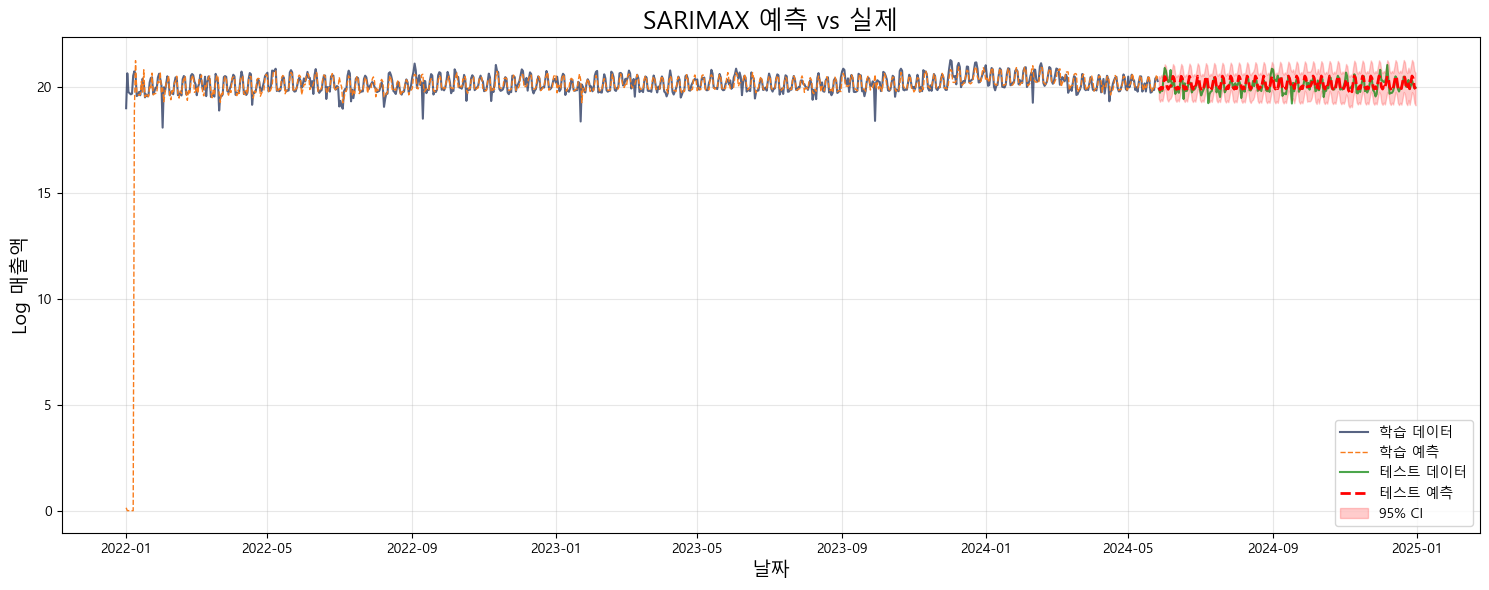

In [590]:
# ========================================
# 9-5) 예측 시각화
# ========================================

fig, ax = plt.subplots(figsize=(15, 6))

# 학습 데이터
ax.plot(y_train.index, y_train, label='학습 데이터', color='#11224E', alpha=0.7)
ax.plot(train_pred.index, train_pred, label='학습 예측', color='#F87B1B', linestyle='--', linewidth=1)

# 테스트 데이터
ax.plot(y_test.index, y_test, label='테스트 데이터', color='green', alpha=0.7)
ax.plot(test_pred.index, test_pred, label='테스트 예측', color='red', linestyle='--', linewidth=2)
ax.fill_between(test_pred_ci.index, test_pred_ci.iloc[:, 0], test_pred_ci.iloc[:, 1],
                alpha=0.2, color='red', label='95% CI')

ax.set_xlabel('날짜', fontsize=14)
ax.set_ylabel('Log 매출액', fontsize=14)
ax.set_title('SARIMAX 예측 vs 실제', fontsize=18)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 화장품소매용 시각화

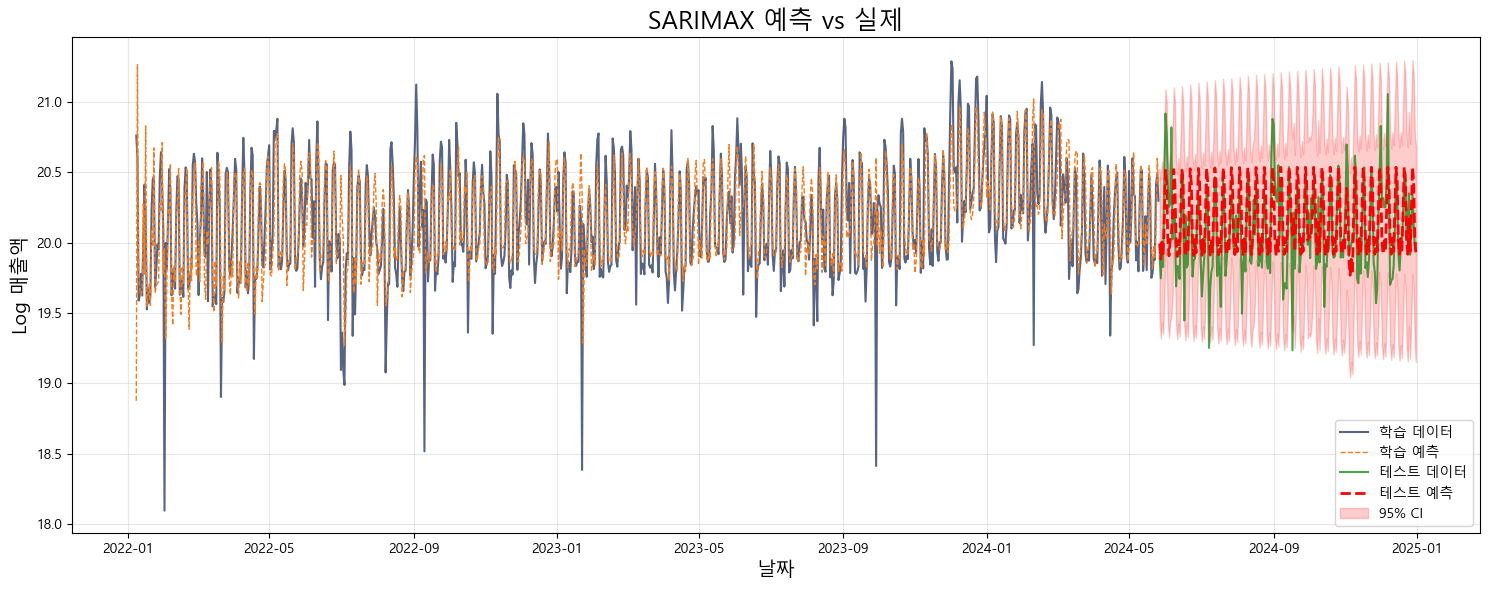

In [592]:
# ========================================
# 9-5) 예측 시각화
# ========================================
start_point = 7  # 넉넉하게 2주 정도 스킵

fig, ax = plt.subplots(figsize=(15, 6))

# 학습 데이터
ax.plot(y_train.iloc[start_point:].index, y_train.iloc[start_point:], label='학습 데이터', color='#11224E', alpha=0.7)
ax.plot(train_pred.iloc[start_point:].index, train_pred.iloc[start_point:], label='학습 예측', color='#F87B1B', linestyle='--', linewidth=1)

# 테스트 데이터
ax.plot(y_test.index, y_test, label='테스트 데이터', color='green', alpha=0.7)
ax.plot(test_pred.index, test_pred, label='테스트 예측', color='red', linestyle='--', linewidth=2)
ax.fill_between(test_pred_ci.index, test_pred_ci.iloc[:, 0], test_pred_ci.iloc[:, 1],
                alpha=0.2, color='red', label='95% CI')

ax.set_xlabel('날짜', fontsize=14)
ax.set_ylabel('Log 매출액', fontsize=14)
ax.set_title('SARIMAX 예측 vs 실제', fontsize=18)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### test

In [1024]:
# 1. 잠정적 모델 (M) 적합
# M: SARIMAX(1, 0, 0)x(1, 0, 1, 7)
model_M_fit = final_model # 사용자님의 final_model

print("="*50)
print("✅ 1. 잠정적 모델 M: SARIMAX(1, 0, 0)x(1, 0, 1, 7) 요약")
print(model_M_fit.summary().tables[1])

✅ 1. 잠정적 모델 M: SARIMAX(1, 0, 0)x(1, 0, 1, 7) 요약
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0842      0.210     -0.401      0.688      -0.496       0.327
is_holiday    -0.2292      0.031     -7.412      0.000      -0.290      -0.169
ar.L1          0.9417      0.015     61.093      0.000       0.911       0.972
ar.S.L7        0.9966      0.002    530.902      0.000       0.993       1.000
ma.S.L7       -0.8422      0.018    -45.619      0.000      -0.878      -0.806
sigma2         0.0856      0.002     36.363      0.000       0.081       0.090


In [1022]:
# 2. 과적합 진단 모델 (M') 적합
# M': SARIMAX(2, 0, 0)x(1, 0, 1, 7)
print("\n" + "="*50)
print("🔍 2. 과적합 진단 모델 M': SARIMAX(2, 0, 0)x(1, 0, 1, 7) 적합 및 요약")

try:
    model_Mp_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(2, 0, 0), # (p+1, d, q)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mp_fit.summary().tables[1])

    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (수정된 코드)")
    
    # 3. 진단 1: 추가된 모수의 유의성 확인 (M' 모델)
    # M'의 .tvalues (t-통계값)에서 'ar.L2'를 직접 참조
    
    if 'ar.L2' in model_Mp_fit.tvalues:
        tstat_ar2_Mp = model_Mp_fit.tvalues['ar.L2']
        
        # t-통계량(z-값)의 절대값으로 유의성 판단
        if np.abs(tstat_ar2_Mp) < 1.96:
            print(f"1. 추가된 모수(ar.L2)의 t-통계량: {tstat_ar2_Mp:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**(추가 모수는 0으로 판단됨).")
        else:
            print(f"1. 추가된 모수(ar.L2)의 t-통계량: {tstat_ar2_Mp:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**(0이 아님).")
    else:
        print("1. 'ar.L2' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 4. 진단 2: 잠정적 모델의 모수 추정값 변화 확인
    # M과 M'의 .params (추정값)에서 'ar.L1' 계수를 직접 참조
    
    if 'ar.L1' in model_M_fit.params and 'ar.L1' in model_Mp_fit.params:
        ar1_M_est = model_M_fit.params['ar.L1']
        ar1_Mp_est = model_Mp_fit.params['ar.L1']
        
        # 변화율 계산 (분모가 0이 아닐 때)
        if ar1_M_est != 0:
            change_rate = np.abs((ar1_Mp_est - ar1_M_est) / ar1_M_est)
            
            print(f"\n2. 잠정적 모델 모수(ar.L1) 추정값 변화:")
            print(f"   M (1,0,0)x(1,0,1,7)의 ar.L1: {ar1_M_est:.4f}")
            print(f"   M'(2,0,0)x(1,0,1,7)의 ar.L1: {ar1_Mp_est:.4f}")
            
            # 변화율이 크지 않다면 (예: 10% 미만) 안정적이라고 판단
            if change_rate < 0.10:
                print(f"   -> 변화율: {change_rate:.2%} (크지 않음).")
                print("   -> **잠정적 모델의 모수 추정값 안정적**.")
            else:
                print(f"   -> 변화율: {change_rate:.2%} (큼).")
                print("   -> **잠정적 모델의 모수 추정값 불안정**(과적합 의심).")
        else:
            print("\n2. 기존 모델(M)의 ar.L1 계수가 0이어서 변화율을 계산할 수 없습니다.")
    else:
         print("\n2. 'ar.L1' 모수를 두 모델에서 비교할 수 없습니다.")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")

✅ 1. 잠정적 모델 M: SARIMAX(1, 0, 0)x(1, 0, 1, 7) 요약
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0842      0.210     -0.401      0.688      -0.496       0.327
is_holiday    -0.2292      0.031     -7.412      0.000      -0.290      -0.169
ar.L1          0.9417      0.015     61.093      0.000       0.911       0.972
ar.S.L7        0.9966      0.002    530.902      0.000       0.993       1.000
ma.S.L7       -0.8422      0.018    -45.619      0.000      -0.878      -0.806
sigma2         0.0856      0.002     36.363      0.000       0.081       0.090

🔍 2. 과적합 진단 모델 M': SARIMAX(2, 0, 0)x(1, 0, 1, 7) 적합 및 요약
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0577      0.022     -2.585      0.010      -0.101      -0.014
is_holiday    -0.2838    

In [1026]:
# 1. 새로운 잠정적 모델 (M') 적합
# M': SARIMAX(2, 0, 0)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 새로운 잠정적 모델 M': SARIMAX(2, 0, 0)x(1, 0, 1, 7)")

try:
    model_Mp_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(2, 0, 0), # (p=2, d=0, q=0)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_Mp_fit.summary().tables[1])

    # 2. 과적합 진단 모델 (M'') 적합
    # M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. 과적합 진단 모델 M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)")

    model_Mpp_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 0), # (p+1=3, d=0, q=0)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mpp_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (p=2 vs p=3)")
    
    # 3-1. 진단 1: 추가된 모수(ar.L3)의 유의성 확인
    if 'ar.L3' in model_Mpp_fit.tvalues:
        tstat_ar3_Mpp = model_Mpp_fit.tvalues['ar.L3']
        
        if np.abs(tstat_ar3_Mpp) < 1.96:
            print(f"1. 추가된 모수(ar.L3)의 t-통계량: {tstat_ar3_Mpp:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**(추가 모수는 0으로 판단됨).")
            print("   -> 💡 긍정적 신호: p=2 차수가 충분할 수 있습니다.")
        else:
            print(f"1. 추가된 모수(ar.L3)의 t-통계량: {tstat_ar3_Mpp:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**(0이 아님).")
            print("   -> ⚠️ 문제 지속: p=2 차수도 부족할 수 있습니다.")
    else:
        print("1. 'ar.L3' 모수를 M'' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1, ar.L2)의 추정값 변화 확인
    print("\n2. 잠정적 모델 모수(ar.L1, ar.L2) 추정값 변화:")
    
    # ar.L1 비교
    if 'ar.L1' in model_Mp_fit.params and 'ar.L1' in model_Mpp_fit.params:
        ar1_Mp_est = model_Mp_fit.params['ar.L1']
        ar1_Mpp_est = model_Mpp_fit.params['ar.L1']
        change_rate_ar1 = np.abs((ar1_Mpp_est - ar1_Mp_est) / ar1_Mp_est) if ar1_Mp_est != 0 else 0
        
        print(f"   [ar.L1] M'(p=2): {ar1_Mp_est:.4f}  ->  M''(p=3): {ar1_Mpp_est:.4f} (변화율: {change_rate_ar1:.2%})")
        if change_rate_ar1 >= 0.10:
             print("     -> ⚠️ ar.L1 계수 불안정")
    
    # ar.L2 비교
    if 'ar.L2' in model_Mp_fit.params and 'ar.L2' in model_Mpp_fit.params:
        ar2_Mp_est = model_Mp_fit.params['ar.L2']
        ar2_Mpp_est = model_Mpp_fit.params['ar.L2']
        change_rate_ar2 = np.abs((ar2_Mpp_est - ar2_Mp_est) / ar2_Mp_est) if ar2_Mp_est != 0 else 0
        
        print(f"   [ar.L2] M'(p=2): {ar2_Mp_est:.4f}  ->  M''(p=3): {ar2_Mpp_est:.4f} (변화율: {change_rate_ar2:.2%})")
        if change_rate_ar2 >= 0.10:
             print("     -> ⚠️ ar.L2 계수 불안정")

    print("\n---")
    print("최종 해석: '1. 추가된 모수(ar.L3)'가 유의하지 않고,")
    print("           '2. 기존 모수(ar.L1, ar.L2)'의 변화율이 작아야")
    print("           p=2가 적절하다고 판단할 수 있습니다.")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")

✅ 1. 새로운 잠정적 모델 M': SARIMAX(2, 0, 0)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0577      0.022     -2.585      0.010      -0.101      -0.014
is_holiday    -0.2838      0.027    -10.682      0.000      -0.336      -0.232
ar.L1          0.5721      0.025     23.019      0.000       0.523       0.621
ar.L2          0.4277      0.025     17.258      0.000       0.379       0.476
ar.S.L7        0.9997      0.001   1757.831      0.000       0.999       1.001
ma.S.L7       -0.8981      0.013    -66.681      0.000      -0.924      -0.872
sigma2         0.0697      0.002     40.185      0.000       0.066       0.073

🔍 2. 과적합 진단 모델 M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0207      0.1

In [1030]:
# 1. 새로운 잠정적 모델 (M'') 적합
# M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 새로운 잠정적 모델 M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)")

try:
    model_Mpp_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 0), # (p=3, d=0, q=0)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_Mpp_fit.summary().tables[1])

    # 2. 과적합 진단 모델 (M''') 적합
    # M''': SARIMAX(4, 0, 0)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. 과적합 진단 모델 M''': SARIMAX(4, 0, 0)x(1, 0, 1, 7)")

    model_Mppp_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(4, 0, 0), # (p+1=4, d=0, q=0)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mppp_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (p=3 vs p=4)")
    
    # 3-1. 진단 1: 추가된 모수(ar.L4)의 유의성 확인
    if 'ar.L4' in model_Mppp_fit.tvalues:
        tstat_ar4_Mppp = model_Mppp_fit.tvalues['ar.L4']
        
        if np.abs(tstat_ar4_Mppp) < 1.96:
            print(f"1. 추가된 모수(ar.L4)의 t-통계량: {tstat_ar4_Mppp:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**(추가 모수는 0으로 판단됨).")
            print("   -> 💡 **테스트 통과**: p=3 차수가 적절하다고 판단할 근거가 됩니다.")
        else:
            print(f"1. 추가된 모수(ar.L4)의 t-통계량: {tstat_ar4_Mppp:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**(0이 아님).")
            print("   -> ⚠️ 문제 지속: p=3 차수도 부족할 수 있습니다.")
    else:
        print("1. 'ar.L4' 모수를 M''' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1, ar.L2, ar.L3)의 추정값 변화 확인
    print("\n2. 잠정적 모델 모수(ar.L1, L2, L3) 추정값 변화:")
    
    # ar.L1 비교
    if 'ar.L1' in model_Mpp_fit.params and 'ar.L1' in model_Mppp_fit.params:
        ar1_Mpp_est = model_Mpp_fit.params['ar.L1']
        ar1_Mppp_est = model_Mppp_fit.params['ar.L1']
        change_rate_ar1 = np.abs((ar1_Mppp_est - ar1_Mpp_est) / ar1_Mpp_est) if ar1_Mpp_est != 0 else 0
        print(f"   [ar.L1] M''(p=3): {ar1_Mpp_est:.4f}  ->  M'''(p=4): {ar1_Mppp_est:.4f} (변화율: {change_rate_ar1:.2%})")

    # ar.L2 비교
    if 'ar.L2' in model_Mpp_fit.params and 'ar.L2' in model_Mppp_fit.params:
        ar2_Mpp_est = model_Mpp_fit.params['ar.L2']
        ar2_Mppp_est = model_Mppp_fit.params['ar.L2']
        change_rate_ar2 = np.abs((ar2_Mppp_est - ar2_Mpp_est) / ar2_Mpp_est) if ar2_Mpp_est != 0 else 0
        print(f"   [ar.L2] M''(p=3): {ar2_Mpp_est:.4f}  ->  M'''(p=4): {ar2_Mppp_est:.4f} (변화율: {change_rate_ar2:.2%})")

    # ar.L3 비교
    if 'ar.L3' in model_Mpp_fit.params and 'ar.L3' in model_Mppp_fit.params:
        ar3_Mpp_est = model_Mpp_fit.params['ar.L3']
        ar3_Mppp_est = model_Mppp_fit.params['ar.L3']
        change_rate_ar3 = np.abs((ar3_Mppp_est - ar3_Mpp_est) / ar3_Mpp_est) if ar3_Mpp_est != 0 else 0
        print(f"   [ar.L3] M''(p=3): {ar3_Mpp_est:.4f}  ->  M'''(p=4): {ar3_Mppp_est:.4f} (변화율: {change_rate_ar3:.2%})")

    print("\n---")
    print("최종 해석: '1. 추가된 모수(ar.L4)'가 유의하지 않고,")
    print("           '2. 기존 모수(ar.L1~L3)'의 변화율이 작으면")
    print("           p=3이 적절하다고 판단할 수 있습니다.")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")

✅ 1. 새로운 잠정적 모델 M'': SARIMAX(3, 0, 0)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0207      0.102     -0.203      0.839      -0.221       0.179
is_holiday    -0.3140      0.025    -12.536      0.000      -0.363      -0.265
ar.L1          0.4301      0.024     17.800      0.000       0.383       0.477
ar.L2          0.2728      0.031      8.676      0.000       0.211       0.334
ar.L3          0.2964      0.026     11.299      0.000       0.245       0.348
ar.S.L7        0.9994      0.001   1326.744      0.000       0.998       1.001
ma.S.L7       -0.9067      0.013    -71.055      0.000      -0.932      -0.882
sigma2         0.0644      0.002     37.386      0.000       0.061       0.068

🔍 2. 과적합 진단 모델 M''': SARIMAX(4, 0, 0)x(1, 0, 1, 7)

모델 적합 또는 비교 중 오류 발생: LU decomposition error.


In [1032]:
# 1. 현재의 잠정적 모델 (M)
# M: SARIMAX(3, 0, 0)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 0)x(1, 0, 1, 7)")

try:
    # M'' 모델을 M_final_p3로 명명
    model_M_final_p3 = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 0), # (p=3, d=0, q=0)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_M_final_p3.summary().tables[1])

    # 2. q 차수 과적합 진단 모델 (M')
    # M': SARIMAX(3, 0, 1)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. q 차수 과적합 진단 모델 M': SARIMAX(3, 0, 1)x(1, 0, 1, 7)")

    model_Mq_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 1), # (p=3, d=0, q=1)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mq_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (q=0 vs q=1)")
    
    # 3-1. 진단 1: 추가된 모수(ma.L1)의 유의성 확인
    if 'ma.L1' in model_Mq_fit.tvalues:
        tstat_ma1 = model_Mq_fit.tvalues['ma.L1']
        
        if np.abs(tstat_ma1) < 1.96:
            print(f"1. 추가된 모수(ma.L1)의 t-통계량: {tstat_ma1:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**.")
            print("   -> 💡 **테스트 통과**: q=0 차수가 적절하다고 판단됩니다.")
        else:
            print(f"1. 추가된 모수(ma.L1)의 t-통계량: {tstat_ma1:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**.")
            print("   -> ⚠️ 문제: q=0 차수도 부족할 수 있습니다.")
    else:
        print("1. 'ma.L1' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1, L2, L3)의 추정값 변화 확인
    print("\n2. 기존 AR 모수(ar.L1, L2, L3) 추정값 변화:")
    
    # ar.L1 비교
    if 'ar.L1' in model_M_final_p3.params and 'ar.L1' in model_Mq_fit.params:
        ar1_M_est = model_M_final_p3.params['ar.L1']
        ar1_Mq_est = model_Mq_fit.params['ar.L1']
        change_rate_ar1 = np.abs((ar1_Mq_est - ar1_M_est) / ar1_M_est) if ar1_M_est != 0 else 0
        print(f"   [ar.L1] M(q=0): {ar1_M_est:.4f}  ->  M'(q=1): {ar1_Mq_est:.4f} (변화율: {change_rate_ar1:.2%})")

    # ar.L2 비교
    if 'ar.L2' in model_M_final_p3.params and 'ar.L2' in model_Mq_fit.params:
        ar2_M_est = model_M_final_p3.params['ar.L2']
        ar2_Mq_est = model_Mq_fit.params['ar.L2']
        change_rate_ar2 = np.abs((ar2_Mq_est - ar2_M_est) / ar2_M_est) if ar2_M_est != 0 else 0
        print(f"   [ar.L2] M(q=0): {ar2_M_est:.4f}  ->  M'(q=1): {ar2_Mq_est:.4f} (변화율: {change_rate_ar2:.2%})")

    # ar.L3 비교
    if 'ar.L3' in model_M_final_p3.params and 'ar.L3' in model_Mq_fit.params:
        ar3_M_est = model_M_final_p3.params['ar.L3']
        ar3_Mq_est = model_Mq_fit.params['ar.L3']
        change_rate_ar3 = np.abs((ar3_Mq_est - ar3_M_est) / ar3_M_est) if ar3_M_est != 0 else 0
        print(f"   [ar.L3] M(q=0): {ar3_M_est:.4f}  ->  M'(q=1): {ar3_Mq_est:.4f} (변화율: {change_rate_ar3:.2%})")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")

✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 0)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf         -0.0207      0.102     -0.203      0.839      -0.221       0.179
is_holiday    -0.3140      0.025    -12.536      0.000      -0.363      -0.265
ar.L1          0.4301      0.024     17.800      0.000       0.383       0.477
ar.L2          0.2728      0.031      8.676      0.000       0.211       0.334
ar.L3          0.2964      0.026     11.299      0.000       0.245       0.348
ar.S.L7        0.9994      0.001   1326.744      0.000       0.998       1.001
ma.S.L7       -0.9067      0.013    -71.055      0.000      -0.932      -0.882
sigma2         0.0644      0.002     37.386      0.000       0.061       0.068

🔍 2. q 차수 과적합 진단 모델 M': SARIMAX(3, 0, 1)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

In [1036]:
# 1. 현재의 잠정적 모델 (M)
# M: SARIMAX(3, 0, 1)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 1)x(1, 0, 1, 7)")

try:
    # model_Mq_fit (이전 단계의 M')을 model_M_p3q1로 명명
    model_M_p3q1 = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 1), # (p=3, d=0, q=1)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_M_p3q1.summary().tables[1])

    # 2. q 차수 과적합 진단 모델 (M')
    # M': SARIMAX(3, 0, 2)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. q 차수 과적합 진단 모델 M': SARIMAX(3, 0, 2)x(1, 0, 1, 7)")

    model_Mq2_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 2), # (p=3, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mq2_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (q=1 vs q=2)")
    
    # 3-1. 진단 1: 추가된 모수(ma.L2)의 유의성 확인
    if 'ma.L2' in model_Mq2_fit.tvalues:
        tstat_ma2 = model_Mq2_fit.tvalues['ma.L2']
        
        if np.abs(tstat_ma2) < 1.96:
            print(f"1. 추가된 모수(ma.L2)의 t-통계량: {tstat_ma2:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**.")
            print("   -> 💡 **테스트 통과**: q=1 차수가 적절하다고 판단됩니다.")
        else:
            print(f"1. 추가된 모수(ma.L2)의 t-통계량: {tstat_ma2:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**.")
            print("   -> ⚠️ 문제: q=1 차수도 부족할 수 있습니다.")
    else:
        print("1. 'ma.L2' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1~L3, ma.L1)의 추정값 변화 확인
    print("\n2. 기존 모수 추정값 변화:")
    
    # 기존 모수 리스트 (AR 3개, MA 1개)
    params_to_check = ['ar.L1', 'ar.L2', 'ar.L3', 'ma.L1']
    
    for param in params_to_check:
        if param in model_M_p3q1.params and param in model_Mq2_fit.params:
            est_M = model_M_p3q1.params[param]
            est_Mq2 = model_Mq2_fit.params[param]
            
            change_rate = np.abs((est_Mq2 - est_M) / est_M) if est_M != 0 else 0
            
            print(f"   [{param}] M(q=1): {est_M:.4f}  ->  M'(q=2): {est_Mq2:.4f} (변화율: {change_rate:.2%})")
            if change_rate >= 0.10: # 10% 이상 변화 시 불안정으로 간주
                print(f"     -> ⚠️ {param} 계수 불안정")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")

✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 1)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf          0.3701      0.050      7.465      0.000       0.273       0.467
is_holiday    -0.0872      0.013     -6.502      0.000      -0.113      -0.061
ar.L1         -0.5048      0.000  -1430.915      0.000      -0.505      -0.504
ar.L2          0.9988      0.004    272.642      0.000       0.992       1.006
ar.L3          0.5060      0.004    144.092      0.000       0.499       0.513
ma.L1          0.8987      0.010     90.257      0.000       0.879       0.918
ar.S.L7        0.9998      0.001   1022.160      0.000       0.998       1.002
ma.S.L7       -0.9051      0.002   -414.166      0.000      -0.909      -0.901
sigma2         0.0805      0.000    686.829      0.000       0.080       0.081

🔍 2. q 차수 과적합 진단 모델 M': SARIMAX(3, 0, 2)x(1, 0, 1, 7)
                 coef    std

In [1038]:
# 1. 현재의 잠정적 모델 (M)
# M: SARIMAX(3, 0, 2)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 2)x(1, 0, 1, 7)")

try:
    # model_Mq2_fit (이전 단계의 M')을 model_M_p3q2로 명명
    model_M_p3q2 = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(3, 0, 2), # (p=3, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_M_p3q2.summary().tables[1])

    # 2. p 차수 과적합 진단 모델 (M')
    # M': SARIMAX(4, 0, 2)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. p 차수 과적합 진단 모델 M': SARIMAX(4, 0, 2)x(1, 0, 1, 7)")

    model_Mp4q2_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(4, 0, 2), # (p=4, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mp4q2_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (p=3 vs p=4 | q=2 고정)")
    
    # 3-1. 진단 1: 추가된 모수(ar.L4)의 유의성 확인
    if 'ar.L4' in model_Mp4q2_fit.tvalues:
        tstat_ar4 = model_Mp4q2_fit.tvalues['ar.L4']
        
        if np.abs(tstat_ar4) < 1.96:
            print(f"1. 추가된 모수(ar.L4)의 t-통계량: {tstat_ar4:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**.")
            print("   -> 💡 **테스트 통과**: (q=2 조건 하에서) p=3 차수가 적절하다고 판단됩니다.")
        else:
            print(f"1. 추가된 모수(ar.L4)의 t-통계량: {tstat_ar4:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**.")
            print("   -> ⚠️ 문제: (q=2 조건 하에서도) p=3 차수는 부족할 수 있습니다.")
    else:
        print("1. 'ar.L4' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1~L3, ma.L1~L2)의 추정값 변화 확인
    print("\n2. 기존 모수 추정값 변화:")
    
    # 기존 모수 리스트 (AR 3개, MA 2개)
    params_to_check = ['ar.L1', 'ar.L2', 'ar.L3', 'ma.L1', 'ma.L2']
    
    for param in params_to_check:
        if param in model_M_p3q2.params and param in model_Mp4q2_fit.params:
            est_M = model_M_p3q2.params[param]
            est_Mp4q2 = model_Mp4q2_fit.params[param]
            
            # 0에 가까운 값(ma.L1)은 변화율이 극단적으로 뛸 수 있으므로 절대값 차이도 고려
            change_rate = np.abs((est_Mp4q2 - est_M) / est_M) if est_M != 0 else np.inf
            abs_diff = np.abs(est_Mp4q2 - est_M)
            
            print(f"   [{param}] M(p=3): {est_M:.4f}  ->  M'(p=4): {est_Mp4q2:.4f} (변화율: {change_rate:.2%}, 절대값 차이: {abs_diff:.4f})")
            
            # ma.L1 처럼 기준값이 0에 가까우면 변화율 대신 절대값 차이로 판단
            if param == 'ma.L1' and abs_diff > 0.1: # 0.1 이상 변하면 불안정으로 간주 (임의의 기준)
                 print(f"     -> ⚠️ {param} 계수 불안정 (절대값 변화 큼)")
            elif param != 'ma.L1' and change_rate >= 0.10: # 10% 이상 변화 시 불안정
                print(f"     -> ⚠️ {param} 계수 불안정 (변화율 큼)")

except Exception as e:
    # 이전에 p=4에서 발생했던 LU decomposition error가 재발할 수 있음
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")
    if "LU decomposition error" in str(e):
        print("---")
        print("💡 해석: p=4 모델이 수치적으로 불안정하여 붕괴했습니다.")
        print("   이는 p=4가 불필요하게 복잡함을 시사하며, p=3이 적절하다는 강력한 근거가 됩니다.")

✅ 1. 현재 잠정적 모델 M: SARIMAX(3, 0, 2)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf          0.0246      0.049      0.497      0.619      -0.072       0.121
is_holiday    -0.2636      0.022    -12.069      0.000      -0.306      -0.221
ar.L1          0.1820      0.027      6.653      0.000       0.128       0.236
ar.L2          0.9968      0.016     61.052      0.000       0.965       1.029
ar.L3         -0.1788      0.026     -6.840      0.000      -0.230      -0.128
ma.L1          0.0060      0.083      0.073      0.942      -0.157       0.169
ma.L2         -0.9937      0.082    -12.086      0.000      -1.155      -0.833
ar.S.L7        0.9988      0.001    790.724      0.000       0.996       1.001
ma.S.L7       -0.9127      0.012    -77.862      0.000      -0.936      -0.890
sigma2         0.0514      0.004     12.974      0.000       0.044       0.059

🔍 2

In [1040]:
# 1. 현재의 잠정적 모델 (M)
# M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 현재 잠정적 모델 M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)")

try:
    # model_Mp4q2_fit (이전 단계의 M')을 model_M_p4q2로 명명
    model_M_p4q2 = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(4, 0, 2), # (p=4, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_M_p4q2.summary().tables[1])

    # 2. p 차수 과적합 진단 모델 (M')
    # M': SARIMAX(5, 0, 2)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. p 차수 과적합 진단 모델 M': SARIMAX(5, 0, 2)x(1, 0, 1, 7)")

    model_Mp5q2_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(5, 0, 2), # (p=5, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mp5q2_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (p=4 vs p=5 | q=2 고정)")
    
    # 3-1. 진단 1: 추가된 모수(ar.L5)의 유의성 확인
    if 'ar.L5' in model_Mp5q2_fit.tvalues:
        tstat_ar5 = model_Mp5q2_fit.tvalues['ar.L5']
        
        if np.abs(tstat_ar5) < 1.96:
            print(f"1. 추가된 모수(ar.L5)의 t-통계량: {tstat_ar5:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**.")
            print("   -> 💡 **테스트 통과**: (q=2 조건 하에서) p=4 차수가 적절하다고 판단됩니다.")
        else:
            print(f"1. 추가된 모수(ar.L5)의 t-통계량: {tstat_ar5:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**.")
            print("   -> ⚠️ 문제: (q=2 조건 하에서도) p=4 차수는 부족할 수 있습니다.")
    else:
        print("1. 'ar.L5' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1~L4, ma.L1~L2)의 추정값 변화 확인
    print("\n2. 기존 모수 추정값 변화:")
    
    # 기존 모수 리스트 (AR 4개, MA 2개)
    params_to_check = ['ar.L1', 'ar.L2', 'ar.L3', 'ar.L4', 'ma.L1', 'ma.L2']
    
    for param in params_to_check:
        if param in model_M_p4q2.params and param in model_Mp5q2_fit.params:
            est_M = model_M_p4q2.params[param]
            est_Mp5q2 = model_Mp5q2_fit.params[param]
            
            change_rate = np.abs((est_Mp5q2 - est_M) / est_M) if est_M != 0 else np.inf
            abs_diff = np.abs(est_Mp5q2 - est_M)
            
            print(f"   [{param}] M(p=4): {est_M:.4f}  ->  M'(p=5): {est_Mp5q2:.4f} (변화율: {change_rate:.2%}, 절대값 차이: {abs_diff:.4f})")
            
            # 0에 가까운 값(ma.L1, ar.L1, ar.L3)은 변화율이 극단적일 수 있음
            if param in ['ma.L1', 'ar.L1', 'ar.L3'] and abs_diff > 0.1:
                 print(f"     -> ⚠️ {param} 계수 불안정 (절대값 변화 큼)")
            elif param not in ['ma.L1', 'ar.L1', 'ar.L3'] and change_rate >= 0.10: # 10% 이상 변화 시 불안정
                print(f"     -> ⚠️ {param} 계수 불안정 (변화율 큼)")

except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")
    if "LU decomposition error" in str(e):
        print("---")
        print("💡 해석: p=5 모델이 수치적으로 불안정하여 붕괴했습니다.")
        print("   이는 p=5가 불필요하게 복잡함을 시사하며, p=4가 적절하다는 강력한 근거가 됩니다.")

✅ 1. 현재 잠정적 모델 M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf          0.0323      0.052      0.628      0.530      -0.069       0.133
is_holiday    -0.2920      0.026    -11.378      0.000      -0.342      -0.242
ar.L1          0.0506      0.018      2.812      0.005       0.015       0.086
ar.L2          1.1589      0.036     32.142      0.000       1.088       1.230
ar.L3         -0.0463      0.015     -3.050      0.002      -0.076      -0.017
ar.L4         -0.1632      0.035     -4.599      0.000      -0.233      -0.094
ma.L1          0.0146      0.078      0.186      0.852      -0.139       0.168
ma.L2         -0.9852      0.073    -13.453      0.000      -1.129      -0.842
ar.S.L7        0.9995      0.001   1345.560      0.000       0.998       1.001
ma.S.L7       -0.8369      0.026    -31.819      0.000      -0.888      -0.785
sigm

In [1042]:
# 1. 현재의 잠정적 모델 (M)
# M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)
print("="*50)
print("✅ 1. 현재 잠정적 모델 M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)")

try:
    # model_M_p4q2 (이전 단계의 M)
    model_M_p4q2 = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(4, 0, 2), # (p=4, d=0, q=2)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)
    
    print(model_M_p4q2.summary().tables[1])

    # 2. q 차수 과적합 진단 모델 (M')
    # M': SARIMAX(4, 0, 3)x(1, 0, 1, 7)
    print("\n" + "="*50)
    print("🔍 2. q 차수 과적합 진단 모델 M': SARIMAX(4, 0, 3)x(1, 0, 1, 7)")

    model_Mq3_fit = SARIMAX(
        daily['amt_log'],
        exog=exog,
        order=(4, 0, 3), # (p=4, d=0, q=3)
        seasonal_order=(1, 0, 1, 7)
    ).fit(disp=False)

    print(model_Mq3_fit.summary().tables[1])

    # --- 3. 진단 결과 비교 ---
    print("\n" + "="*50)
    print("✨ 과적합 진단 결과 비교 (q=2 vs q=3 | p=4 고정)")
    
    # 3-1. 진단 1: 추가된 모수(ma.L3)의 유의성 확인
    if 'ma.L3' in model_Mq3_fit.tvalues:
        tstat_ma3 = model_Mq3_fit.tvalues['ma.L3']
        
        if np.abs(tstat_ma3) < 1.96:
            print(f"1. 추가된 모수(ma.L3)의 t-통계량: {tstat_ma3:.2f}")
            print("   -> **절대값 1.96 미만**: 추가된 모수가 **유의하지 않음**.")
            print("   -> 💡 **테스트 통과**: (p=4 조건 하에서) q=2 차수가 적절하다고 판단됩니다.")
        else:
            print(f"1. 추가된 모수(ma.L3)의 t-통계량: {tstat_ma3:.2f}")
            print("   -> **절대값 1.96 이상**: 추가된 모수가 **유의함**.")
            print("   -> ⚠️ 문제: (p=4 조건 하에서도) q=2 차수는 부족할 수 있습니다.")
    else:
        print("1. 'ma.L3' 모수를 M' 모델에서 찾을 수 없습니다.")

    # 3-2. 진단 2: 기존 모수(ar.L1~L4, ma.L1~L2)의 추정값 변화 확인
    print("\n2. 기존 모수 추정값 변화:")
    
    params_to_check = ['ar.L1', 'ar.L2', 'ar.L3', 'ar.L4', 'ma.L1', 'ma.L2']
    
    for param in params_to_check:
        if param in model_M_p4q2.params and param in model_Mq3_fit.params:
            est_M = model_M_p4q2.params[param]
            est_Mq3 = model_Mq3_fit.params[param]
            
            change_rate = np.abs((est_Mq3 - est_M) / est_M) if est_M != 0 else np.inf
            abs_diff = np.abs(est_Mq3 - est_M)
            
            print(f"   [{param}] M(q=2): {est_M:.4f}  ->  M'(q=3): {est_Mq3:.4f} (변화율: {change_rate:.2%}, 절대값 차이: {abs_diff:.4f})")
            
            # 0에 가까운 값들은 변화율 대신 절대값 차이로 판단
            if param in ['ma.L1', 'ar.L1', 'ar.L3'] and abs_diff > 0.1:
                 print(f"     -> ⚠️ {param} 계수 불안정 (절대값 변화 큼)")
            elif param not in ['ma.L1', 'ar.L1', 'ar.L3'] and change_rate >= 0.10: # 10% 이상 변화 시 불안정
                print(f"     -> ⚠️ {param} 계수 불안정 (변화율 큼)")


except Exception as e:
    print(f"\n모델 적합 또는 비교 중 오류 발생: {e}")
    if "LU decomposition error" in str(e) or "failed to converge" in str(e):
        print("---")
        print("💡 해석: q=3 모델이 수치적으로 불안정하여 붕괴했습니다.")
        print("   이는 q=3이 불필요하게 복잡함을 시사하며, q=2가 적절하다는 강력한 근거가 됩니다.")

✅ 1. 현재 잠정적 모델 M: SARIMAX(4, 0, 2)x(1, 0, 1, 7)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_bf          0.0323      0.052      0.628      0.530      -0.069       0.133
is_holiday    -0.2920      0.026    -11.378      0.000      -0.342      -0.242
ar.L1          0.0506      0.018      2.812      0.005       0.015       0.086
ar.L2          1.1589      0.036     32.142      0.000       1.088       1.230
ar.L3         -0.0463      0.015     -3.050      0.002      -0.076      -0.017
ar.L4         -0.1632      0.035     -4.599      0.000      -0.233      -0.094
ma.L1          0.0146      0.078      0.186      0.852      -0.139       0.168
ma.L2         -0.9852      0.073    -13.453      0.000      -1.129      -0.842
ar.S.L7        0.9995      0.001   1345.560      0.000       0.998       1.001
ma.S.L7       -0.8369      0.026    -31.819      0.000      -0.888      -0.785
sigm

# 최종 요약 & 보고서

In [ ]:
print("\n" + "=" * 70)
print("【최종 분석 보고서】")
print("=" * 70)

print(f"""
【분석 개요】
- 분석 대상: 수원시 카드 결제 데이터
- 분석 기간: 2022-01-01 ~ 2024-12-31
- 분석 목표: 블랙프라이데이 매출 증가 효과 검증
- 샘플 크기: {len(daily)}일

【데이터 전처리】
- 일별 집계: 매출액 합산, 거래 건수 합산
- 로그 변환: ln(1 + amt)로 분산 안정화
- 더미 변수: 블프({daily['is_bf'].sum()}일), 공휴일({daily['is_holiday'].sum()}일)
- 이상치 제거: 롤링 MAD 기준으로 {daily['is_outlier'].sum()}개 탐지

【시계열 분석】
- 정상성: ADF p={adf_p_diff:.4f} (차분={d_final})
- 계절성: STL로 주간 패턴 확인 (s=7)
- 모형: SARIMAX({best_order[0]},{best_order[1]},{best_order[2]})×({best_order[3]},{best_order[4]},{best_order[5]},{best_order[6]})
- AIC: {best_aic:.2f}

【주요 결과】
블랙프라이데이 효과:
  - 계수: {bf_coef:.4f} (log scale)
  - 퍼센트 변화: {bf_pct:+.2f}%
  - 95% 신뢰구간: [{bf_pct_ci_low:+.2f}%, {bf_pct_ci_high:+.2f}%]
  - p-value: {bf_pval:.6f}
  - 유의성: {'✓ 통계적으로 유의 (p<0.05)' if bf_pval < 0.05 else '✗ 통계적으로 유의 아님 (p≥0.05)'}

공휴일 효과 (참고):
  - 계수: {hol_coef:.4f}
  - 퍼센트 변화: {hol_pct:+.2f}%
  - p-value: {hol_pval:.6f}

【모형 진단】
- 잔차 자기상관: Ljung-Box p={lb_test['lb_pvalue'].iloc[0]:.4f} {'✓' if lb_test['lb_pvalue'].iloc[0] > 0.05 else '⚠️'}
- 정규성: Shapiro-Wilk p={shapiro_p:.4f}
- 과적합: RMSE 비율={rmse_ratio:.2f}, MAPE 비율={mape_ratio:.2f}

【최종 결론】
{f"✓ 블랙프라이데이는 통계적으로 유의한 양의 매출 효과를 가집니다. ({bf_pct:+.1f}%, p={bf_pval:.6f})" if bf_pval < 0.05 and bf_coef > 0 else "✗ 블랙프라이데이는 통계적으로 유의한 효과를 보이지 않습니다."}

【권장사항】
1. 매년 11월 넷째 주에 블랙프라이데이 프로모션 추진 효과 확대
2. 공휴일 대비 별도의 마케팅 전략 수립
3. 주간 패턴을 고려한 재고 관리 및 인력 배치

分析 수행일: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
""")

print("=" * 70)
print("분석 완료!")
print("=" * 70)


# TEST

- 현재 파이프라인은 더미 변수 포함 회귀(SARIMAX)를 수행
- 즉, is_bf의 계수 유의성 검정으로, 블프 효과가 0인지 아닌지를 테스트

만약 "베이스라인 예측 대비 초과/미만 여부"를 검정하고 싶다면?
- 사전 학습 베이스라인 vs 실제 비교 블록을 추가해야함
  - 블프 이전 데이터(또는 블프 제외 데이터)로 SARIMA/SARIMAX를 학습
  - 블프 기간 예측을 생성
  - 실제값이 95% 예측구간 상한을 얼마나 초과하는지 일수 및 크기로 요약해 통계적으로 유의한 이탈인지 점검


In [ ]:
# 베이스라인: 블프 제외 학습
train_mask = (daily.index < '2024-11-01')  # 필요에 따라 범위 조정
for y in [2022, 2023]:
    s,e = get_bf_period_third_to_fourth(y)
    train_mask &= ~((daily.index >= s) & (daily.index <= e))

train = daily[train_mask]
test = daily[(daily.index >= '2024-11-01') & (daily.index <= '2024-12-31')]

base_model = SARIMAX(train['amt_log'],
                     order=(1,1,1),
                     seasonal_order=(1,0,1,7)).fit(disp=False)
fcst = base_model.get_forecast(steps=len(test))
pred = fcst.predicted_mean
ci = fcst.conf_int()

excess_days = (test['amt_log'] > ci.iloc[:,1]).sum()
excess_ratio = excess_days / len(test)
print(f"베이스라인 상한 초과 일수: {excess_days}/{len(test)} ({excess_ratio:.0%})")
